# 15. The Last Two Orders of Magnitude

**The question.** The lab runs live at 1e5–1e7. The designs it studies are for 1e8–1e9.
What does the smoke→mac→node ladder let us *honestly* say about the two orders of
magnitude nobody will ever run here? Four instruments, each with its own failure mode:
**SCL-01** fits error-vs-n on small rungs and asks whether the fit predicts a held-out
larger rung *within its own prediction interval* — and whether the operating threshold
transfers by law (a √(2 ln n) extreme-value shift) or decays when frozen. **SCL-02** fits
the non-match similarity tail with a GPD whose diagnostics gate is ENFORCED — ξ is quoted
only where the tail earned it, and predicted false-positive counts are checked against
exactly-counted ones at 2–3× growth. **EFF-01** prices compression (PCA truncation ×
numeric precision) in ER metrics, because 1e9 × 384-d fp32 = 1.5 TB does not fit the
node. **SCL-03/04** assemble the measured coefficients into a cost model with a real
single-node ceiling, and the measured NC ambiguity rates into an irreducible-ambiguity
budget.

**The star of this notebook is a visual convention, not a number.** Every figure below
renders through `er_lab.reporting.figures`, whose rails draw **measured points solid**
and **projected points dashed, over a shaded span, under a diagonal EXTRAPOLATED
watermark**, with the basis stamped into every caption. A reader skimming the figures can
always tell what was measured from what is arithmetic on assumptions — that discipline is
the deliverable; the smoke-tier numbers are its demonstration.

**Scope honesty, up front.** At smoke the "ladder" tops out at ~3.2e4 records standing in
for the 1e5→1e7 mac/node ladder — same code path, tier only via config, and the
`# [RUN-IN-TARGET mac|node]` placard prices the real rungs from THIS run's measured
coefficients. One trained encoder, one seed, one corpus draw, one ladder permutation:
every verdict below says "demonstration" and quotes the MET-04 replicate bar as the
caution. No entity appears on both sides of the train/eval boundary (`met07_splits`
entity-disjoint scheme, PLAN §5). The corpus is `historical_50k`-derived (public
historical records); NC data enters ONLY as registered aggregate statistics (met06
rates, alignment counts) — **no NC person-level value appears anywhere in this notebook,
so there is nothing to mask** (DATA_GOVERNANCE.md: aggregates only).

In [1]:
import time

import faiss
import numpy as np
import pandas as pd
from IPython.display import display

from er_lab.blocking import ann
from er_lab.cluster.schemes import transitive_closure
from er_lab.config import config_hash, load_config_from_env, set_all_seeds
from er_lab.data.schema import NON_TEXT_ROLES, ROLES
from er_lab.eval.bootstrap import bootstrap_ci
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.models.encoders import build_encoder
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.scale.costmodel import NODE_RAM_GB, CostModel, SingleNodeCeilingError
from er_lab.scale.curves import entity_ladder, fit_scaling, validate_extrapolation
from er_lab.scale.evt import diagnostics_pass, fit_gpd_tail, predict_fp_count
from er_lab.serialize import serialize_frame
from er_lab.train.loop import train_encoder

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()
SECTION_TIMES: list[tuple[str, float]] = []


def tick(label: str, t0: float) -> None:
    """Record and print one section's wall-clock — the smoke budget is measured, not vibes."""
    secs = time.time() - t0
    SECTION_TIMES.append((label, secs))
    print(f"[section timing] {label}: {secs:.0f}s")

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

The encoder shape and step budget are the same tier table as notebooks 09/12/13, so the
NB12 recipe transfers verbatim (asserted against the registered recipe below, never
assumed). The ladder sizes are the tier's scaling rungs — the smoke ladder is the
methodology rehearsal for the 1e5→1e7 mac/node ladder, at the same *relative* span.
Protocol constants (candidate budget k, the pairwise-precision target, the EVT threshold
quantiles) are identical at every tier; analysis budgets (bootstrap replicates, non-match
sample sizes, the exact-counting cutoff) scale with tier. Smoke budget for the whole
notebook: **<= ~30 min uncontended on the 4-CPU container** (a concurrent workload can
inflate wall-clock 2–4x; per-section timings print at the end).

In [3]:
TIER = str(cfg.run.tier)
LADDER_SIZES = {
    "smoke": (2_000, 5_000, 10_000, 20_000, 32_000),
    "mid": (100_000, 200_000, 400_000, 700_000, 1_000_000),
    "target": (100_000, 320_000, 1_000_000, 3_200_000, 10_000_000),
    "analytical": (2_000, 5_000, 10_000, 20_000, 32_000),
}[TIER]
N_FIT_RUNGS = 3  # fit on the smallest three rungs; the top two are held out (protocol)
EXTRAP_MULTS = (3.2, 10.0, 32.0, 100.0)  # two decades past the ladder — the 1e7->1e9 span
K_CAND = 10  # candidate budget (bas02's noise-slice k; matched, not tuned here)
PAIR_PREC_TARGET = 0.99  # tau0 selection target on the smallest rung (PLAN §5 pairwise)
EVT_QUANTILES = (0.95, 0.99, 0.995)  # scale.evt threshold quantiles (module default)
STEPS_BY_TIER = {"smoke": 250, "mid": 2000, "target": 4000, "analytical": 250}
TRAIN_N = {"smoke": 3_000, "mid": None, "target": None, "analytical": 3_000}
MODEL_SHAPE = {
    "smoke": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
    "mid": {"dim": 256, "layers": 4, "heads": 4, "max_len": 192},
    "target": {"dim": 384, "layers": 6, "heads": 6, "max_len": 192},
    "analytical": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
}[TIER]
STEPS = STEPS_BY_TIER[TIER]
ENC_BATCH = 256
N_BOOT_PC = {"smoke": 400, "mid": 1000, "target": 2000, "analytical": 400}[TIER]
N_BOOT_F = {"smoke": 300, "mid": 500, "target": 1000, "analytical": 300}[TIER]
N_BOOT_EVT = {"smoke": 200, "mid": 300, "target": 400, "analytical": 200}[TIER]
NM_SAMPLE = {"smoke": 300_000, "mid": 1_000_000, "target": 2_000_000,
             "analytical": 300_000}[TIER]
EXACT_MAX_RECORDS = {"smoke": 40_000, "mid": 120_000, "target": 120_000,
                     "analytical": 40_000}[TIER]
PAIR_SAMPLE = {"smoke": 2_000_000, "mid": 5_000_000, "target": 10_000_000,
               "analytical": 2_000_000}[TIER]
PRIMARY_SEED = int(cfg.run.seed)

cfg.model.kind = "scratch_char"
cfg.model.dim = MODEL_SHAPE["dim"]
cfg.model.layers = MODEL_SHAPE["layers"]
cfg.model.heads = MODEL_SHAPE["heads"]
cfg.model.max_len = MODEL_SHAPE["max_len"]
cfg.train.steps = STEPS
BATCH = int(cfg.train.batch_size)
print(f"tier={TIER}: ladder {LADDER_SIZES} (fit on the smallest {N_FIT_RUNGS}), k={K_CAND}, "
      f"tau0 target precision {PAIR_PREC_TARGET}; encoder {MODEL_SHAPE}, steps={STEPS}, "
      f"batch={BATCH}, train-slice budget {TRAIN_N[TIER]}; boots pc={N_BOOT_PC} "
      f"F={N_BOOT_F} evt={N_BOOT_EVT}; non-match sample {NM_SAMPLE:,}, exact pair counting "
      f"up to {EXACT_MAX_RECORDS:,} records (sampled fallback {PAIR_SAMPLE:,} pairs)")

tier=smoke: ladder (2000, 5000, 10000, 20000, 32000) (fit on the smallest 3), k=10, tau0 target precision 0.99; encoder {'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128}, steps=250, batch=64, train-slice budget 3000; boots pc=400 F=300 evt=200; non-match sample 300,000, exact pair counting up to 40,000 records (sampled fallback 2,000,000 pairs)


## 1. The arena: upstreams, discipline, instruments

Everything loads through the registry at this run's tier. `bas02_blocking_frontier` (DAG
upstream) supplies the **encoder recipe** this notebook retrains once — loss, regime,
budget, field set, serialization, all read from its meta — plus NB12's measured blocking
coefficients. `clu01_clustering_scores` (DAG upstream) supplies the measured clustering
throughput the cost model consumes and the operating-point context the ladder inherits.
`met07_splits` enforces the eval discipline; `met04_power_table` supplies the replicate
bar every single-seed verdict is read through; NB00's `smoke_check` corroborates the
throughput coefficients.

`TEXT_ROLES` inherits notebook 08's **measured decision**: `full_name` is EXCLUDED — a
verbatim join of the name parts that doubles serialized length (forcing truncation at the
smoke byte window) and goes stale under injected noise, leaking the clean name past it.

In [4]:
t_sec = time.time()
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
bas02, bas02_meta = registry.load("bas02_blocking_frontier", tier=cfg.run.tier)
clu01, clu01_meta = registry.load("clu01_clustering_scores", tier=cfg.run.tier)
splits, _splits_meta = registry.load("met07_splits", tier=cfg.run.tier)
met04, met04_meta = registry.load("met04_power_table", tier=cfg.run.tier)
smoke_chk, smoke_chk_meta = registry.load("smoke_check", tier=cfg.run.tier)

CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
BAS02_PROVENANCE = (
    f"bas02_blocking_frontier run {bas02_meta['created_at']} "
    f"(cfg {bas02_meta['config_hash']}, tier {bas02_meta['tier']})"
)
CLU01_PROVENANCE = (
    f"clu01_clustering_scores run {clu01_meta['created_at']} "
    f"(cfg {clu01_meta['config_hash']}, tier {clu01_meta['tier']})"
)
RECIPE = dict(bas02_meta["extra"]["encoder_recipe"])
print(f"corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records / {corpus['entity_id'].nunique():,} entities; "
      f"source={corpus['source'].unique().tolist()} (public historical records; NC enters "
      "this notebook only as registered aggregate statistics — nothing person-level to mask)")
print(f"recipe source: {BAS02_PROVENANCE}")
print(f"  NB12 recipe: loss={RECIPE['loss']}, regime={RECIPE['regime']}, "
      f"miner={RECIPE['miner']}, augment={RECIPE['augment']}, steps={RECIPE['steps']} x "
      f"batch {RECIPE['batch']}, model={RECIPE['model']} ({RECIPE['n_params']:,} params)")
print(f"clustering coefficients source: {CLU01_PROVENANCE}")
if str(bas02_meta["tier"]) == TIER:
    assert int(RECIPE["steps"]) == STEPS and int(RECIPE["batch"]) == BATCH, (
        f"recipe budget {RECIPE['steps']}x{RECIPE['batch']} != tier table {STEPS}x{BATCH}"
    )
    assert dict(RECIPE["model"]) == MODEL_SHAPE, (
        f"recipe shape {RECIPE['model']} != tier table {MODEL_SHAPE}"
    )
cfg.model.kind = "scratch_char" if RECIPE["regime"] == "scratch_char" else "pretrained"

corpus: calibrated_corpus run 2026-08-26T02:41:13.372218+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records / 2,507 entities; source=['historical_50k'] (public historical records; NC enters this notebook only as registered aggregate statistics — nothing person-level to mask)
recipe source: bas02_blocking_frontier run 2026-08-26T07:51:03.901636+00:00 (cfg 98af614e2bcd, tier smoke)
  NB12 recipe: loss=infonce, regime=scratch_char, miner=inbatch, augment=none, steps=250 x batch 64, model={'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128} (330,880 params)
clustering coefficients source: clu01_clustering_scores run 2026-08-26T08:33:37.543132+00:00 (cfg 98af614e2bcd, tier smoke)


In [5]:
# NB08's measured field-set decision, inherited (see the section note above).
TEXT_ROLES = ["given_name", "family_name", "dob", "city", "zip", "sex"]
assert TEXT_ROLES == list(RECIPE["text_roles"]), (
    f"TEXT_ROLES {TEXT_ROLES} != the registered recipe's {RECIPE['text_roles']}"
)
KEEP_COLS = ["record_id", "entity_id"] + TEXT_ROLES
_loop_roles = [c for c in KEEP_COLS if c in ROLES and c not in NON_TEXT_ROLES]
assert _loop_roles == TEXT_ROLES, (
    f"training-loop role rule would diverge from TEXT_ROLES on KEEP_COLS: {_loop_roles}"
)
print(f"TEXT_ROLES (full_name excluded, NB08 decision) = {TEXT_ROLES}")

SCHEME = "entity_disjoint"
train_ids = set(splits["schemes"][SCHEME]["train"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
straddle = splits["metadata"]["checks"][SCHEME]["entities_straddling"]
assert straddle == 0, "entity-disjoint split must have zero straddling entities (PLAN §5)"
arena = corpus.reset_index(drop=True)
N_ARENA = len(arena)
train_full = corpus[corpus["record_id"].isin(train_ids)].reset_index(drop=True)
eval_full = corpus[corpus["record_id"].isin(eval_ids)].reset_index(drop=True)
TRUTH_ALL = arena.set_index(arena["record_id"].astype(str))["entity_id"]
EVAL_ENTS = set(eval_full["entity_id"].astype(str).unique())
print(f"split {SCHEME}: {len(train_full):,} train / {len(eval_full):,} eval records "
      f"({train_full['entity_id'].nunique():,} / {len(EVAL_ENTS):,} entities, 0 straddling). "
      "Ladders block WHOLE rungs (train entities are honest distractors in the pool); every "
      "metric is scored on eval-half records only.")

SER_SCHEME, SER_MISSING = str(cfg.serialize.scheme), str(cfg.serialize.missing)
assert {"scheme": SER_SCHEME, "missing": SER_MISSING} == dict(RECIPE["serialization"]), (
    "serialization drifted from the registered recipe"
)
ARENA_TEXTS = serialize_frame(
    arena, text_roles=TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING
).tolist()
ARENA_POS = pd.Series(np.arange(N_ARENA), index=arena["record_id"].astype(str))
print(f"serialization: scheme={SER_SCHEME} missing={SER_MISSING} (recipe-locked)")

TEXT_ROLES (full_name excluded, NB08 decision) = ['given_name', 'family_name', 'dob', 'city', 'zip', 'sex']
split entity_disjoint: 16,164 train / 16,095 eval records (1,252 / 1,255 entities, 0 straddling). Ladders block WHOLE rungs (train entities are honest distractors in the pool); every metric is scored on eval-half records only.


serialization: scheme=colval missing=token (recipe-locked)


In [6]:
# The MET-04 caution bar for everything downstream of ONE trained encoder (same read as
# notebooks 12/13: residual-inclusive from the meta when present, else computed and said so).
SD_REPLICATE = float(met04_meta["extra"]["sd_replicate"])
_comps = met04[met04["kind"] == "variance_component"].set_index("component")["variance"]
if "detect_bar_residual_inclusive" in met04_meta["extra"]:
    BAR_FULL = float(met04_meta["extra"]["detect_bar_residual_inclusive"])
    BAR_SRC = "read from met04_power_table meta"
else:
    BAR_FULL = float(2.0 * np.sqrt(2.0) * np.sqrt(_comps.sum()))
    BAR_SRC = ("computed here as 2*sqrt(2)*sqrt(seed+noise_draw+residual) — the registered "
               "meta carries only the residual-EXCLUSIVE sd_replicate")
print(f"MET-04 bars (B3F1 units; table scope: {met04['scope'].iloc[0]}): "
      f"sd_replicate={SD_REPLICATE:.4f}, residual-inclusive single-seed bar {BAR_FULL:.4f} "
      f"({BAR_SRC}). PC/precision are different metrics — the bar is quoted as the "
      "order-of-magnitude caution for anything downstream of ONE trained encoder.")

MET-04 bars (B3F1 units; table scope: smoke_pilot): sd_replicate=0.0305, residual-inclusive single-seed bar 0.0865 (read from met04_power_table meta). PC/precision are different metrics — the bar is quoted as the order-of-magnitude caution for anything downstream of ONE trained encoder.


In [7]:
# NB13's family-name-frequency instrument, inherited: corpus-wide record-level frequency
# (case/whitespace-normalized for counting only), terciles over non-missing names, a pair's
# stratum = the band of its COMMONER member ('missing' when either side is blank).
FAM_NORM = corpus["family_name"].astype("string").str.strip().str.upper()
FAM_FREQ = FAM_NORM.value_counts()
_rec_freq = FAM_NORM.map(FAM_FREQ).astype("Float64").to_numpy(dtype=float, na_value=np.nan)
TERCILE_EDGES = tuple(float(q) for q in np.nanquantile(_rec_freq, [1 / 3, 2 / 3]))
BAND_ALL = np.where(
    _rec_freq <= TERCILE_EDGES[0], 0, np.where(_rec_freq <= TERCILE_EDGES[1], 1, 2)
).astype(np.int8)
BAND_ALL[np.isnan(_rec_freq)] = 3  # 'missing' band; np.maximum makes it dominate a pair
STRATA = ("rare", "mid", "common", "missing")
print(f"family-name instrument (NB13's): {FAM_FREQ.size:,} distinct names, tercile edges at "
      f"{TERCILE_EDGES[0]:.0f}/{TERCILE_EDGES[1]:.0f} occurrences; record bands: "
      + ", ".join(f"{s}={int((BAND_ALL == b).sum()):,}" for b, s in enumerate(STRATA)))
tick("§1 arena + upstreams + instruments", t_sec)

family-name instrument (NB13's): 2,662 distinct names, tercile edges at 16/31 occurrences; record bands: rare=9,998, mid=9,709, common=9,680, missing=2,872
[section timing] §1 arena + upstreams + instruments: 1s


## 2. The conjectures — registered before the encoder trains or a single rung exists

Both cards go in now: SCL-01 consumes SCL-02's gate machinery (the per-rung EVT arm), so
both must be pre-registered before ANY ladder computation. The decision rules live inside
the prediction fields; the verdicts at the ends of sections 5 and 6 score exactly them.

In [8]:
_ = conjecture_card(
    card_id="SCL-01",
    conjecture=(
        "The smoke-to-node ladder can honestly speak about the next orders of magnitude "
        "only if two things hold on rungs it can afford: the error-vs-n curve is lawful — "
        "a 2-parameter fit on the small rungs predicts the largest held-out rung within "
        "its own prediction interval — and the operating threshold transfers by law "
        "rather than by freeze: a tau frozen at the smallest rung sheds accepted-pair "
        "precision as the candidate pool grows, while shifting it at the Gaussian "
        "extreme-value rate sqrt(2 ln n) approximately holds it."
    ),
    pressure=(
        "corpus size n along a nested entity-preserving ladder "
        "(scale.curves.entity_ladder over calibrated_corpus, one seed-fixed entity "
        "permutation; smoke sizes {2000, 5000, 10000, 20000, 32000}, mac/node 1e5->1e7 "
        "per the tier table), everything else frozen: ONE NB12-recipe encoder retrained "
        "once (recipe read from bas02_blocking_frontier meta, budget asserted from the "
        "training history), ann_flat k=10 candidates over each FULL rung, raw-cosine "
        "scoring, and three threshold-transfer arms — fixed: tau0, the loosest cosine "
        "attaining pairwise precision 0.99 on the smallest rung's eval-half candidate "
        "pairs (highest-attainable fallback flagged loudly); shifted: tau0 + s0*(sqrt(2 "
        "ln n) - sqrt(2 ln n0)) with s0 the tail-local Gaussian scale of the smallest "
        "rung's non-match cosines, (q_0.999 - q_0.99)/(z_0.999 - z_0.99); per-rung EVT: "
        "the GPD-inverted threshold holding the smallest rung's all-pairs FP budget per "
        "record, available only at rungs where scale.evt.diagnostics_pass passes on that "
        "rung's non-match sample"
    ),
    property=(
        "the error-vs-n curve itself: eval-half pair-miss rate (1 - pair completeness at "
        "k=10) per rung, fitted by scale.curves.fit_scaling (powerlaw primary, loglinear "
        "reported) on the smallest three rungs ONLY, judged at the held-out largest rung "
        "by scale.curves.validate_extrapolation against the fit's own 95% prediction "
        "interval; plus each arm's per-rung accepted-pair precision"
    ),
    metric=(
        "per rung and per arm: pair completeness with entity-bootstrap 95% CIs, "
        "accepted-pair pairwise precision with Wilson 95% CIs, and B-cubed entity-F of "
        "transitive closure at the arm's threshold with entity-unit BCa CIs — registered "
        "in scl01_scaling_fits, with the measured-solid/extrapolated-dashed curve panel "
        "in scl01_curve_panel"
    ),
    prediction=(
        "P1: the powerlaw fit of the pair-miss rate on the smallest three rungs covers "
        "the held-out largest rung within its own 95% prediction interval "
        "(validate_extrapolation within_pi=True; with three points the PI is wide — "
        "dof=1 — and that honesty cost is stated, not hidden). P2: threshold transfer is "
        "the real hazard — the fixed arm's accepted-pair precision at the largest rung "
        "sits below its smallest-rung value, and the sqrt(2 ln n)-shifted arm deviates "
        "less: |prec_shift(n_top) - prec(n0)| < |prec_fixed(n_top) - prec(n0)|. Decision "
        "rule, pre-registered: REFUTED iff within_pi is False at the largest rung, OR "
        "the shifted arm's absolute precision deviation at the largest rung is >= the "
        "fixed arm's while the fixed arm's drop exceeds 0.01 (the shift bought nothing "
        "where there was something to buy); CONFIRMED iff P1 and P2 both hold; "
        "UNEXPLAINED otherwise. The per-rung EVT arm is reported wherever its gate "
        "passes and cannot flip the outcome. Extrapolated points beyond the ladder are "
        "drawn (dashed, watermarked) ONLY if P1 holds — a failed validation forfeits the "
        "extrapolation, and the notebook says so instead of drawing it. If any fit "
        "rung's miss rate is exactly 0 the powerlaw form is infeasible and the "
        "pre-registered fallback is the loglinear form on pair completeness, same PI "
        "test. Single seed, one corpus draw, one ladder permutation: a demonstration of "
        "the methodology — the adjudicating ladder is 1e5->1e7 on mac/node (placard)."
    ),
    registry=registry,
)

### Conjecture card `SCL-01`

| | |
|---|---|
| **Conjecture** | The smoke-to-node ladder can honestly speak about the next orders of magnitude only if two things hold on rungs it can afford: the error-vs-n curve is lawful — a 2-parameter fit on the small rungs predicts the largest held-out rung within its own prediction interval — and the operating threshold transfers by law rather than by freeze: a tau frozen at the smallest rung sheds accepted-pair precision as the candidate pool grows, while shifting it at the Gaussian extreme-value rate sqrt(2 ln n) approximately holds it. |
| **Pressure (dial)** | corpus size n along a nested entity-preserving ladder (scale.curves.entity_ladder over calibrated_corpus, one seed-fixed entity permutation; smoke sizes {2000, 5000, 10000, 20000, 32000}, mac/node 1e5->1e7 per the tier table), everything else frozen: ONE NB12-recipe encoder retrained once (recipe read from bas02_blocking_frontier meta, budget asserted from the training history), ann_flat k=10 candidates over each FULL rung, raw-cosine scoring, and three threshold-transfer arms — fixed: tau0, the loosest cosine attaining pairwise precision 0.99 on the smallest rung's eval-half candidate pairs (highest-attainable fallback flagged loudly); shifted: tau0 + s0*(sqrt(2 ln n) - sqrt(2 ln n0)) with s0 the tail-local Gaussian scale of the smallest rung's non-match cosines, (q_0.999 - q_0.99)/(z_0.999 - z_0.99); per-rung EVT: the GPD-inverted threshold holding the smallest rung's all-pairs FP budget per record, available only at rungs where scale.evt.diagnostics_pass passes on that rung's non-match sample |
| **Embedding property** | the error-vs-n curve itself: eval-half pair-miss rate (1 - pair completeness at k=10) per rung, fitted by scale.curves.fit_scaling (powerlaw primary, loglinear reported) on the smallest three rungs ONLY, judged at the held-out largest rung by scale.curves.validate_extrapolation against the fit's own 95% prediction interval; plus each arm's per-rung accepted-pair precision |
| **System metric** | per rung and per arm: pair completeness with entity-bootstrap 95% CIs, accepted-pair pairwise precision with Wilson 95% CIs, and B-cubed entity-F of transitive closure at the arm's threshold with entity-unit BCa CIs — registered in scl01_scaling_fits, with the measured-solid/extrapolated-dashed curve panel in scl01_curve_panel |
| **Pre-registered prediction** | P1: the powerlaw fit of the pair-miss rate on the smallest three rungs covers the held-out largest rung within its own 95% prediction interval (validate_extrapolation within_pi=True; with three points the PI is wide — dof=1 — and that honesty cost is stated, not hidden). P2: threshold transfer is the real hazard — the fixed arm's accepted-pair precision at the largest rung sits below its smallest-rung value, and the sqrt(2 ln n)-shifted arm deviates less: |prec_shift(n_top) - prec(n0)| < |prec_fixed(n_top) - prec(n0)|. Decision rule, pre-registered: REFUTED iff within_pi is False at the largest rung, OR the shifted arm's absolute precision deviation at the largest rung is >= the fixed arm's while the fixed arm's drop exceeds 0.01 (the shift bought nothing where there was something to buy); CONFIRMED iff P1 and P2 both hold; UNEXPLAINED otherwise. The per-rung EVT arm is reported wherever its gate passes and cannot flip the outcome. Extrapolated points beyond the ladder are drawn (dashed, watermarked) ONLY if P1 holds — a failed validation forfeits the extrapolation, and the notebook says so instead of drawing it. If any fit rung's miss rate is exactly 0 the powerlaw form is infeasible and the pre-registered fallback is the loglinear form on pair completeness, same PI test. Single seed, one corpus draw, one ladder permutation: a demonstration of the methodology — the adjudicating ladder is 1e5->1e7 on mac/node (placard). |

*Immutable — sha256 `2b4304f7ba24`; registered before the affected runs, never edited (PLAN §5).*


In [9]:
_ = conjecture_card(
    card_id="SCL-02",
    conjecture=(
        "Non-match cosine tails of a trained person-record encoder are short, not heavy: "
        "within every family-name-frequency stratum the excess distribution over a high "
        "threshold is GPD with shape xi <= 0 (bounded cosine support forces a finite "
        "endpoint), common names shift the tail's LOCATION upward rather than changing "
        "its law, and a base-rung GPD fit therefore predicts the false-positive count at "
        "2-3x corpus growth."
    ),
    pressure=(
        "corpus growth along the same nested entity-preserving ladder: non-match "
        "(cross-entity) cosine samples among eval-half records of the base rung (the "
        "largest fit rung — 10000 at smoke), stratified by NB13's family-name-frequency "
        "instrument (tercile band of the commoner member: rare/mid/common, plus "
        "missing), fitted by scale.evt.fit_gpd_tail at threshold quantiles {0.95, 0.99, "
        "0.995} with scale.evt.diagnostics_pass ENFORCED as the quoting gate — xi is "
        "quoted only where it passes; failing strata display the gate's reasons instead"
    ),
    property=(
        "per-stratum GPD tail shape xi and its threshold stability, QQ agreement on the "
        "unit-exponential scale (the gate's diagnostics, rendered as data), and the tail "
        "location u at the 0.99 quantile contrasted across strata"
    ),
    metric=(
        "predicted vs exactly-counted false-positive (cross-entity exceedance) counts "
        "above the SCL-01 fixed threshold tau0 at the 2x and ~3.2x record-growth rungs "
        "(comparison counts grow ~4x/~10x), per stratum, with predict_fp_count's 95% "
        "bootstrap intervals — registered in scl02_tail_fits"
    ),
    prediction=(
        "P1: every stratum that passes the diagnostics gate has fitted xi <= 0.05 at "
        "every threshold quantile in {0.95, 0.99, 0.995} (xi <= 0 up to estimation "
        "slack). P2: the tail location u at the 0.99 quantile is strictly highest in "
        "the common stratum — common names move where the tail lives, not its law. P3 "
        "(subordinate, cannot flip the outcome): in gate-passing strata the "
        "exactly-counted exceedances above tau0 at the growth rungs fall inside "
        "predict_fp_count's 95% bootstrap interval from the base-rung fit. Decision "
        "rule, pre-registered: REFUTED iff any gate-passing stratum has xi > 0.05 at "
        "ALL of its fitted quantiles; CONFIRMED iff at least two strata pass the gate "
        "and P1 and P2 both hold; UNEXPLAINED otherwise — explicitly including the "
        "outcome where the gate fails almost everywhere, which is itself the "
        "demonstration the ENFORCED gate exists to force. Single seed, one corpus draw: "
        "a demonstration; the 1e6/1e7-pool tail fits on mac/node adjudicate."
    ),
    registry=registry,
)

### Conjecture card `SCL-02`

| | |
|---|---|
| **Conjecture** | Non-match cosine tails of a trained person-record encoder are short, not heavy: within every family-name-frequency stratum the excess distribution over a high threshold is GPD with shape xi <= 0 (bounded cosine support forces a finite endpoint), common names shift the tail's LOCATION upward rather than changing its law, and a base-rung GPD fit therefore predicts the false-positive count at 2-3x corpus growth. |
| **Pressure (dial)** | corpus growth along the same nested entity-preserving ladder: non-match (cross-entity) cosine samples among eval-half records of the base rung (the largest fit rung — 10000 at smoke), stratified by NB13's family-name-frequency instrument (tercile band of the commoner member: rare/mid/common, plus missing), fitted by scale.evt.fit_gpd_tail at threshold quantiles {0.95, 0.99, 0.995} with scale.evt.diagnostics_pass ENFORCED as the quoting gate — xi is quoted only where it passes; failing strata display the gate's reasons instead |
| **Embedding property** | per-stratum GPD tail shape xi and its threshold stability, QQ agreement on the unit-exponential scale (the gate's diagnostics, rendered as data), and the tail location u at the 0.99 quantile contrasted across strata |
| **System metric** | predicted vs exactly-counted false-positive (cross-entity exceedance) counts above the SCL-01 fixed threshold tau0 at the 2x and ~3.2x record-growth rungs (comparison counts grow ~4x/~10x), per stratum, with predict_fp_count's 95% bootstrap intervals — registered in scl02_tail_fits |
| **Pre-registered prediction** | P1: every stratum that passes the diagnostics gate has fitted xi <= 0.05 at every threshold quantile in {0.95, 0.99, 0.995} (xi <= 0 up to estimation slack). P2: the tail location u at the 0.99 quantile is strictly highest in the common stratum — common names move where the tail lives, not its law. P3 (subordinate, cannot flip the outcome): in gate-passing strata the exactly-counted exceedances above tau0 at the growth rungs fall inside predict_fp_count's 95% bootstrap interval from the base-rung fit. Decision rule, pre-registered: REFUTED iff any gate-passing stratum has xi > 0.05 at ALL of its fitted quantiles; CONFIRMED iff at least two strata pass the gate and P1 and P2 both hold; UNEXPLAINED otherwise — explicitly including the outcome where the gate fails almost everywhere, which is itself the demonstration the ENFORCED gate exists to force. Single seed, one corpus draw: a demonstration; the 1e6/1e7-pool tail fits on mac/node adjudicate. |

*Immutable — sha256 `27ed3277c75d`; registered before the affected runs, never edited (PLAN §5).*


## 3. One encoder, retrained to the registered recipe — budget stated

Identical to notebooks 12/13 by construction: the same entity-complete train slice (same
subsample seed), the same recipe read from the registry, the same seed into
`train.loop.train_encoder` — deterministic under seed, so this *is* the NB12 encoder,
re-derived rather than re-invented. The budget is the recipe's exact optimizer-step count
at the recipe's batch size — asserted from the training history, wall-clock measured. The
encoder is trained ONCE for the whole ladder: SCL-01's pressure is n, and retraining per
rung would confound the curve with training noise (stated, deliberate).

In [10]:
def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut.

    (Same notebook-local helper as notebooks 05/09/12/13 — a shared home in er_lab.data
    would serve; reported as a package gap.)
    """
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


t_sec = time.time()
train_slice = entity_complete_subsample(
    train_full, TRAIN_N[TIER], np.random.default_rng(PRIMARY_SEED)
)[KEEP_COLS]
assert len(train_slice) == int(RECIPE["train_slice"]["records"]) or str(
    bas02_meta["tier"]
) != TIER, "train slice diverged from the registered recipe's — not an identical retrain"
print(f"train slice: {len(train_slice):,} records / {train_slice['entity_id'].nunique():,} "
      "entities (entity-complete, same construction+seed as NB12/13)")

set_all_seeds(PRIMARY_SEED)
encoder = build_encoder(cfg)
N_PARAMS = int(sum(p.numel() for p in encoder.parameters()))
_t0 = time.time()
encoder, hist = train_encoder(
    encoder, train_slice, cfg, loss_name=str(RECIPE["loss"]), miner_name=str(RECIPE["miner"]),
    augment_kind=str(RECIPE["augment"]), steps=STEPS, seed=PRIMARY_SEED,
)
TRAIN_SECS = time.time() - _t0
assert len(hist) == STEPS and int(hist["step"].iloc[-1]) == STEPS, (
    f"budget violation: expected exactly {STEPS} optimizer steps, history shows {len(hist)}"
)
print(f"trained ONCE for the whole ladder: {RECIPE['loss']}/{RECIPE['miner']}/"
      f"{RECIPE['augment']}, {STEPS} steps x batch {BATCH} (asserted from history), "
      f"{N_PARAMS:,} params -> {TRAIN_SECS:.0f}s (NB12 measured "
      f"{RECIPE['train_secs']:.0f}s for the same budget); "
      f"final train loss {float(hist['loss'].tail(20).mean()):.4f}")
tick("§3a recipe retrain", t_sec)

train slice: 3,010 records / 222 entities (entity-complete, same construction+seed as NB12/13)


trained ONCE for the whole ladder: infonce/inbatch/none, 250 steps x batch 64 (asserted from history), 330,880 params -> 54s (NB12 measured 517s for the same budget); final train loss 1.0417
[section timing] §3a recipe retrain: 54s


In [11]:
t_sec = time.time()
_t0 = time.time()
EMB = encoder.encode(ARENA_TEXTS, batch_size=ENC_BATCH)
ENCODE_SECS = time.time() - _t0
ENC_RATE = N_ARENA / ENCODE_SECS
print(f"encoded {N_ARENA:,} records -> ({EMB.shape[0]:,}, {EMB.shape[1]}) in "
      f"{ENCODE_SECS:.0f}s = {ENC_RATE:,.0f} rec/s on this container (rows L2-normalized, "
      "so a pair's dot product IS its cosine). This is SCL-03's encode_rps coefficient; "
      f"NB12 measured {float(bas02_meta['extra']['encode']['records_per_sec']):,.0f} rec/s "
      "for the same budget on this container (contention moves it), and NB00's smoke_check "
      f"measured {float(smoke_chk['measured']['charbyte_encode_texts_per_s']):,.0f} texts/s "
      "on the UNTRAINED 256-d default shape — three mutually corroborating measurements.")
tick("§3b encode", t_sec)

encoded 32,259 records -> (32,259, 128) in 22s = 1,469 rec/s on this container (rows L2-normalized, so a pair's dot product IS its cosine). This is SCL-03's encode_rps coefficient; NB12 measured 385 rec/s for the same budget on this container (contention moves it), and NB00's smoke_check measured 207 texts/s on the UNTRAINED 256-d default shape — three mutually corroborating measurements.
[section timing] §3b encode: 22s


In [12]:
# Shared scoring/eval helpers (notebook-local; the candidate-set PC bootstrap remains a
# package gap first noted in NB12 — er_lab.eval.bootstrap targets clusterings).
def pair_cosines(a_ids: pd.Series, b_ids: pd.Series, emb: np.ndarray) -> np.ndarray:
    """Cosine per pair from an arena-aligned embedding matrix (positional lookup)."""
    ia = ARENA_POS.loc[a_ids.astype(str)].to_numpy()
    ib = ARENA_POS.loc[b_ids.astype(str)].to_numpy()
    return np.einsum("ij,ij->i", emb[ia], emb[ib]).astype(float)


def true_pair_table(frame: pd.DataFrame) -> pd.DataFrame:
    """All unordered same-entity pairs of *frame* as DataFrame[a, b, entity, key], a<b."""
    rows: list[tuple[str, str, str]] = []
    for ent, grp in frame.groupby("entity_id", sort=True):
        ids = sorted(grp["record_id"].astype(str))
        for i in range(len(ids) - 1):
            for j in range(i + 1, len(ids)):
                rows.append((ids[i], ids[j], str(ent)))
    out = pd.DataFrame(rows, columns=["a", "b", "entity"])
    out["key"] = out["a"] + "||" + out["b"]
    return out


def pc_entity_ci(found: np.ndarray, ent_labels: pd.Series, seed: int,
                 n_boot: int = N_BOOT_PC) -> tuple[float, float, float]:
    """(point, lo, hi): pair completeness with a percentile entity-bootstrap 95% CI."""
    codes, _ = pd.factorize(ent_labels)
    n_ent = int(codes.max()) + 1
    f_e = np.bincount(codes, weights=found.astype(float), minlength=n_ent)
    t_e = np.bincount(codes, minlength=n_ent).astype(float)
    idx = np.random.default_rng(seed).integers(0, n_ent, size=(n_boot, n_ent))
    with np.errstate(invalid="ignore"):
        reps = f_e[idx].sum(axis=1) / t_e[idx].sum(axis=1)
    return (float(found.mean()), float(np.nanpercentile(reps, 2.5)),
            float(np.nanpercentile(reps, 97.5)))


def wilson_ci(k: int, n: int) -> tuple[float, float]:
    """Wilson 95% interval for a binomial proportion (pair-unit precision CI, stated)."""
    if n == 0:
        return (float("nan"), float("nan"))
    z = 1.959963984540054
    ph = k / n
    denom = 1.0 + z * z / n
    center = ph + z * z / (2 * n)
    half = z * np.sqrt(ph * (1 - ph) / n + z * z / (4 * n * n))
    return (float((center - half) / denom), float((center + half) / denom))


def precision_threshold(scores: np.ndarray, labels: np.ndarray, target: float) -> dict:
    """Loosest score threshold attaining pairwise precision >= target (NB13's helper).

    Whole tie groups are kept or dropped together; when the target is unattainable the
    best-attainable point returns with attained=False (PLAN §5: report loudly, never
    switch protocol silently).
    """
    order = np.argsort(-scores, kind="stable")
    s, y = scores[order], labels[order].astype(float)
    cum_tp = np.cumsum(y)
    prec = cum_tp / np.arange(1, len(s) + 1)
    last = np.flatnonzero(np.r_[s[1:] != s[:-1], True])
    prec_c, thr_c = prec[last], s[last]
    rec_c = cum_tp[last] / max(float(y.sum()), 1.0)
    feasible = np.flatnonzero(prec_c >= target)
    i = feasible[-1] if len(feasible) else int(np.argmax(prec_c))
    return {"threshold": float(thr_c[i]), "attained": bool(len(feasible)),
            "precision": float(prec_c[i]), "recall": float(rec_c[i]),
            "max_attainable": float(prec_c.max())}


def nonmatch_sample(x: np.ndarray, ent: np.ndarray, band: np.ndarray, m: int,
                    seed: int) -> tuple[np.ndarray, np.ndarray]:
    """Uniform cross-entity pair cosines (+ pair stratum band), sampled with replacement."""
    rng = np.random.default_rng(seed)
    cos_parts: list[np.ndarray] = []
    band_parts: list[np.ndarray] = []
    got = 0
    while got < m:
        take = int(1.3 * (m - got)) + 64
        i = rng.integers(0, len(x), size=take)
        j = rng.integers(0, len(x), size=take)
        keep = (i != j) & (ent[i] != ent[j])
        i, j = i[keep], j[keep]
        cos_parts.append(np.einsum("ij,ij->i", x[i], x[j]))
        band_parts.append(np.maximum(band[i], band[j]))
        got += len(i)
    return (np.concatenate(cos_parts)[:m].astype(float),
            np.concatenate(band_parts)[:m].astype(np.int8))


def tail_exceed_counts(x: np.ndarray, ent: np.ndarray, band: np.ndarray, tau: float,
                       seed: int) -> dict:
    """Cross-entity pair counts and score exceedances >= tau, per stratum band.

    Exact (block matmul over ALL unordered cross-entity pairs) when the record count is
    within the tier's EXACT_MAX_RECORDS budget; otherwise a uniform PAIR_SAMPLE estimate
    scaled to the arithmetic cross-pair total — the same code path at every tier, with
    the method recorded in the result (the mac/node placard prices both).
    """
    n = len(x)
    ent_sizes = np.bincount(pd.factorize(ent)[0])
    cross_total = n * (n - 1) // 2 - int((ent_sizes * (ent_sizes - 1) // 2).sum())
    t0 = time.time()
    n_pairs = np.zeros(4, dtype=np.int64)
    n_exc = np.zeros(4, dtype=np.int64)
    if n <= EXACT_MAX_RECORDS:
        step = 2048
        col = np.arange(n)
        for i0 in range(0, n, step):
            i1 = min(i0 + step, n)
            s = x[i0:i1] @ x.T
            valid = (col[None, :] > np.arange(i0, i1)[:, None]) & (
                ent[i0:i1, None] != ent[None, :]
            )
            pb = np.maximum(band[i0:i1, None], band[None, :])
            exc = s >= tau
            for b in range(4):
                m = valid & (pb == b)
                n_pairs[b] += int(m.sum())
                n_exc[b] += int((m & exc).sum())
        method = "exact"
        assert int(n_pairs.sum()) == cross_total, "exact pair count disagrees with arithmetic"
    else:
        cos, pband = nonmatch_sample(x, ent, band, PAIR_SAMPLE, seed)
        for b in range(4):
            m = pband == b
            share = float(m.mean())
            n_pairs[b] = round(share * cross_total)
            n_exc[b] = round(float((m & (cos >= tau)).sum()) / PAIR_SAMPLE * cross_total)
        method = f"sampled({PAIR_SAMPLE:,})"
    return {"n_pairs": n_pairs, "n_exceed": n_exc, "secs": time.time() - t0,
            "method": method, "cross_total": cross_total}


def gpd_threshold_for_rate(fit: dict, p_target: float) -> tuple[float | None, str | None]:
    """Invert the GPD survival formula: the threshold whose exceedance prob is p_target.

    Uses the fitted threshold with the largest u whose p_exceed still exceeds p_target
    (the most local valid fit — predict_fp_count's selection rule, run in reverse).
    """
    per_u = fit["fits"]
    eligible = [q for q, f in per_u.items() if f["p_exceed"] > p_target > 0]
    if not eligible:
        return None, (f"no fitted threshold has p_exceed > p_target={p_target:.2e} "
                      "(budget looser than the lowest fitted tail, or zero)")
    q_sel = max(eligible, key=lambda q: per_u[q]["u"])
    f = per_u[q_sel]
    ratio = p_target / f["p_exceed"]
    if abs(f["xi"]) < 1e-9:
        t = f["u"] - f["sigma"] * np.log(ratio)
    else:
        t = f["u"] + f["sigma"] / f["xi"] * (ratio ** (-f["xi"]) - 1.0)
    return float(min(t, 1.0)), None


print("helpers defined (candidate-set PC bootstrap + exact tail counter are notebook-local "
      "— package gaps, listed at the close)")

helpers defined (candidate-set PC bootstrap + exact tail counter are notebook-local — package gaps, listed at the close)


## 4. The ladder: five rungs, one encoder, three threshold arms

`entity_ladder` samples ENTITIES, not records — a record subsample would thin every
entity and confound "more records" with "less duplication" (the module docstring's
argument); rungs are nested, so rung-to-rung deltas share entities. Each rung is blocked
WHOLE (`ann_flat`, k=10 — the recall-ceiling index; train entities are honest pool
distractors), and scored on eval-half records only: pair completeness on the rung's
eval true pairs, then the three arms on its eval-half candidate pairs. The smallest rung
fixes everything the arms transfer: `tau0` (loosest cosine attaining pairwise precision
0.99 there), `s0` (its non-match tail-local scale), and the EVT arm's FP budget per
record. Entity-F is transitive closure at the arm's threshold — NB13's scheme ledger
showed scheme choice is second-order at fixed precision, so the naive scheme is the
honest common denominator here.

In [13]:
t_sec = time.time()
LADDER = entity_ladder(arena, sizes=list(LADDER_SIZES), seed=PRIMARY_SEED)
EV_PAIRS_FULL = true_pair_table(eval_full)
print(f"ladder built: {len(LADDER)} nested entity-preserving rungs "
      f"(targets {list(LADDER)}); full-corpus eval truth: {len(EV_PAIRS_FULL):,} true pairs "
      f"over {EV_PAIRS_FULL['entity'].nunique():,} multi-record eval entities")

RUNG_ROWS: list[dict] = []
ARM_ROWS: list[dict] = []
RUNG_DATA: dict[int, dict] = {}
TAU0 = SIGMA0 = B0 = np.nan
N0 = N0_EV = 0
TAU0_ATTAINED = True
Z999 = 3.090232306167813  # Phi^-1(0.999)
Z99 = 2.3263478740408408  # Phi^-1(0.99)


def process_rung(size: int, r_i: int) -> None:
    """Block one rung, score PC + the three arms on its eval half, stash SCL-02 inputs."""
    global TAU0, SIGMA0, B0, N0, N0_EV, TAU0_ATTAINED
    rung = LADDER[size]
    n = len(rung)
    pos = ARENA_POS.loc[rung["record_id"].astype(str)].to_numpy()
    t0 = time.time()
    cand = ann.candidates(rung, EMB[pos], k=K_CAND, index="flat")
    ann_secs = time.time() - t0

    ev_rows = rung["entity_id"].astype(str).isin(EVAL_ENTS).to_numpy()
    ev_ids = set(rung.loc[ev_rows, "record_id"].astype(str))
    ev_pos = pos[ev_rows]
    rung_ents = set(rung["entity_id"].astype(str).unique())
    tp = EV_PAIRS_FULL[EV_PAIRS_FULL["entity"].isin(rung_ents)]
    keys = set((cand["a"].astype(str) + "||" + cand["b"].astype(str)).tolist())
    found = tp["key"].isin(keys).to_numpy()
    pc, pc_lo, pc_hi = pc_entity_ci(found, tp["entity"], seed=PRIMARY_SEED + 100 + r_i)

    ce = cand[cand["a"].astype(str).isin(ev_ids) & cand["b"].astype(str).isin(ev_ids)].copy()
    ce["a"], ce["b"] = ce["a"].astype(str), ce["b"].astype(str)
    ce_cos = pair_cosines(ce["a"], ce["b"], EMB)
    ce_lab = (TRUTH_ALL.loc[ce["a"]].to_numpy() == TRUTH_ALL.loc[ce["b"]].to_numpy())

    x_ev = EMB[ev_pos].astype(np.float32)
    ent_ev = pd.factorize(TRUTH_ALL.iloc[ev_pos].to_numpy())[0].astype(np.int32)
    band_ev = BAND_ALL[ev_pos]
    nm_cos, nm_band = nonmatch_sample(x_ev, ent_ev, band_ev, NM_SAMPLE,
                                      seed=PRIMARY_SEED + 200 + r_i)
    evt_fit = fit_gpd_tail(nm_cos, u_quantiles=EVT_QUANTILES)
    gate_ok, gate_reasons = diagnostics_pass(evt_fit)
    n_ev = int(ev_rows.sum())
    n_cmp = n_ev * (n_ev - 1) // 2 - len(tp)

    if r_i == 0:
        res0 = precision_threshold(ce_cos, ce_lab, PAIR_PREC_TARGET)
        TAU0, TAU0_ATTAINED = res0["threshold"], res0["attained"]
        SIGMA0 = float((np.quantile(nm_cos, 0.999) - np.quantile(nm_cos, 0.99))
                       / (Z999 - Z99))
        N0, N0_EV = n, n_ev
        counts0 = tail_exceed_counts(x_ev, ent_ev, band_ev, TAU0,
                                     seed=PRIMARY_SEED + 900)
        fp0 = int(counts0["n_exceed"].sum())
        B0 = (fp0 if fp0 > 0 else 0.5) / n_ev  # zero-FP base -> <1-expected-pair budget
        print(f"  smallest rung fixes the arms: tau0={TAU0:.4f} "
              f"(pairwise precision target {PAIR_PREC_TARGET}, attained={TAU0_ATTAINED}"
              + ("" if TAU0_ATTAINED else
                 f", max attainable {res0['max_attainable']:.4f} <-- PLAN §5 fallback, "
                 "reported loudly") + ")")
        print(f"    tail-local scale s0={SIGMA0:.4f} (non-match q999-q99 slope); all-pairs "
              f"FP budget b0={B0:.4f}/record ({fp0} exceedances over "
              f"{counts0['cross_total']:,} cross pairs, {counts0['method']})")

    arms: dict[str, tuple[float, str | None]] = {
        "fixed_tau0": (TAU0, None),
        "sqrt2logn_shift": (
            TAU0 + SIGMA0 * (np.sqrt(2 * np.log(n)) - np.sqrt(2 * np.log(N0))), None),
    }
    if gate_ok:
        tau_evt, why = gpd_threshold_for_rate(evt_fit, (B0 * n_ev) / max(n_cmp, 1))
        arms["evt_gate"] = (np.nan if tau_evt is None else tau_evt, why)
    else:
        arms["evt_gate"] = (np.nan, "diagnostics_pass FAILED: " + "; ".join(gate_reasons))

    truth_ev = pd.Series(TRUTH_ALL.loc[list(ev_ids)].to_numpy(),
                         index=pd.Index(list(ev_ids)))
    rec_index = truth_ev.index
    for arm, (tau, why) in arms.items():
        if not np.isfinite(tau):
            ARM_ROWS.append({"row_type": "arm", "n": n, "target": size, "arm": arm,
                             "tau": np.nan, "n_accepted": 0, "n_positive": 0,
                             "pair_precision": np.nan, "prec_lo": np.nan,
                             "prec_hi": np.nan, "entity_f": np.nan, "f_lo": np.nan,
                             "f_hi": np.nan, "evt_gate_pass": gate_ok,
                             "evt_reason": why or "", "basis": "MEASURED"})
            print(f"  [{arm} n={n:,}] UNAVAILABLE — {why}")
            continue
        acc = ce_cos >= tau
        n_acc, n_pos = int(acc.sum()), int(ce_lab[acc].sum())
        prec = n_pos / n_acc if n_acc else np.nan
        p_lo, p_hi = wilson_ci(n_pos, n_acc)
        pairs = pd.DataFrame({"a": ce["a"], "b": ce["b"],
                              "prob": np.clip((ce_cos + 1.0) / 2.0, 0.0, 1.0)})
        pred = transitive_closure(pairs, threshold=(tau + 1.0) / 2.0, records=rec_index)
        fres = bootstrap_ci(pred, truth_ev, "bcubed_f1", unit="entity", n_boot=N_BOOT_F,
                            seed=PRIMARY_SEED)
        ARM_ROWS.append({"row_type": "arm", "n": n, "target": size, "arm": arm,
                         "tau": float(tau), "n_accepted": n_acc, "n_positive": n_pos,
                         "pair_precision": prec, "prec_lo": p_lo, "prec_hi": p_hi,
                         "entity_f": fres["point"], "f_lo": fres["ci_low"],
                         "f_hi": fres["ci_high"], "evt_gate_pass": gate_ok,
                         "evt_reason": "" if arm != "evt_gate" else "gate passed",
                         "basis": "MEASURED"})
        print(f"  [{arm} n={n:,}] tau={tau:.4f}: {n_acc:,} accepted, precision="
              f"{prec:.4f} [{p_lo:.4f},{p_hi:.4f}], entity-F={fres['point']:.4f} "
              f"[{fres['ci_low']:.4f},{fres['ci_high']:.4f}]")

    RUNG_ROWS.append({"row_type": "rung", "n": n, "target": size, "n_eval_records": n_ev,
                      "n_eval_entities": int(tp["entity"].nunique()),
                      "n_true_pairs": len(tp), "pc": pc, "pc_lo": pc_lo, "pc_hi": pc_hi,
                      "miss": 1.0 - pc, "n_cand_pairs": len(cand),
                      "n_cand_eval_pairs": len(ce), "ann_secs": ann_secs,
                      "basis": "MEASURED"})
    RUNG_DATA[size] = {"x": x_ev, "ent": ent_ev, "band": band_ev, "n": n, "n_ev": n_ev,
                       "n_cmp": n_cmp, "n_true": len(tp), "nm_cos": nm_cos,
                       "nm_band": nm_band, "fit": evt_fit, "gate_ok": gate_ok,
                       "gate_reasons": gate_reasons}
    print(f"[rung n={n:,} (target {size:,})] {len(cand):,} candidates in {ann_secs:.1f}s; "
          f"eval: {n_ev:,} records, {len(tp):,} true pairs -> PC={pc:.4f} "
          f"[{pc_lo:.4f},{pc_hi:.4f}] (miss {1 - pc:.4f}); pooled EVT gate "
          f"{'PASS' if gate_ok else 'FAIL(' + str(len(gate_reasons)) + ' reasons)'}")


for _r_i, _size in enumerate(sorted(LADDER)[:3]):
    process_rung(_size, _r_i)
tick("§4a ladder rungs 1-3", t_sec)

ladder built: 5 nested entity-preserving rungs (targets [2000, 5000, 10000, 20000, 32000]); full-corpus eval truth: 187,785 true pairs over 991 multi-record eval entities


  smallest rung fixes the arms: tau0=0.8993 (pairwise precision target 0.99, attained=True)
    tail-local scale s0=0.0707 (non-match q999-q99 slope); all-pairs FP budget b0=0.0686/record (58 exceedances over 348,420 cross pairs, exact)
  [fixed_tau0 n=2,015] tau=0.8993: 3,110 accepted, precision=0.9900 [0.9859,0.9930], entity-F=0.7295 [0.6741,0.7841]
  [sqrt2logn_shift n=2,015] tau=0.8993: 3,110 accepted, precision=0.9900 [0.9859,0.9930], entity-F=0.7295 [0.6741,0.7841]
  [evt_gate n=2,015] tau=0.8990: 3,112 accepted, precision=0.9894 [0.9851,0.9924], entity-F=0.7295 [0.6741,0.7841]
[rung n=2,015 (target 2,000)] 13,738 candidates in 0.0s; eval: 846 records, 9,015 true pairs -> PC=0.4125 [0.3724,0.4669] (miss 0.5875); pooled EVT gate PASS


  [fixed_tau0 n=5,003] tau=0.8993: 9,138 accepted, precision=0.9744 [0.9709,0.9774], entity-F=0.6948 [0.6584,0.7270]
  [sqrt2logn_shift n=5,003] tau=0.9153: 8,422 accepted, precision=0.9891 [0.9866,0.9911], entity-F=0.6695 [0.6304,0.7006]
  [evt_gate n=5,003] tau=0.9230: 8,162 accepted, precision=0.9911 [0.9888,0.9929], entity-F=0.6508 [0.6166,0.6873]
[rung n=5,003 (target 5,000)] 34,789 candidates in 0.2s; eval: 2,363 records, 26,127 true pairs -> PC=0.4098 [0.3758,0.4482] (miss 0.5902); pooled EVT gate PASS


  [fixed_tau0 n=10,024] tau=0.8993: 19,624 accepted, precision=0.9607 [0.9579,0.9633], entity-F=0.6632 [0.6454,0.6891]
  [sqrt2logn_shift n=10,024] tau=0.9270: 17,292 accepted, precision=0.9910 [0.9895,0.9923], entity-F=0.6215 [0.5990,0.6452]
  [evt_gate n=10,024] tau=0.9314: 16,964 accepted, precision=0.9921 [0.9907,0.9933], entity-F=0.6121 [0.5873,0.6351]
[rung n=10,024 (target 10,000)] 69,898 candidates in 0.5s; eval: 4,934 records, 59,718 true pairs -> PC=0.3708 [0.3394,0.4008] (miss 0.6292); pooled EVT gate PASS
[section timing] §4a ladder rungs 1-3: 8s


In [14]:
# (the two held-out rungs in their own cell: the top rung carries the biggest index build,
# the largest closure, and the exact tail counting — contention headroom)
t_sec = time.time()
for _r_i, _size in enumerate(sorted(LADDER)[3:], start=3):
    process_rung(_size, _r_i)
rungs_df = pd.DataFrame(RUNG_ROWS)
arms_df = pd.DataFrame(ARM_ROWS)
display(rungs_df[["n", "target", "n_eval_records", "n_true_pairs", "pc", "pc_lo", "pc_hi",
                  "miss", "n_cand_pairs", "ann_secs"]].round(4))
display(arms_df[["n", "arm", "tau", "n_accepted", "pair_precision", "prec_lo", "prec_hi",
                 "entity_f", "f_lo", "f_hi", "evt_gate_pass"]].round(4))
tick("§4b ladder rungs 4-5 + tables", t_sec)

  [fixed_tau0 n=20,007] tau=0.8993: 37,829 accepted, precision=0.9335 [0.9309,0.9359], entity-F=0.6380 [0.6236,0.6544]
  [sqrt2logn_shift n=20,007] tau=0.9381: 30,827 accepted, precision=0.9932 [0.9922,0.9940], entity-F=0.6054 [0.5882,0.6244]


  [evt_gate n=20,007] tau=0.9308: 31,932 accepted, precision=0.9882 [0.9869,0.9893], entity-F=0.6179 [0.6010,0.6365]
[rung n=20,007 (target 20,000)] 139,697 candidates in 1.9s; eval: 9,536 records, 109,423 true pairs -> PC=0.3669 [0.3468,0.3875] (miss 0.6331); pooled EVT gate PASS


  [fixed_tau0 n=32,038] tau=0.8993: 65,660 accepted, precision=0.9154 [0.9133,0.9175], entity-F=0.6151 [0.6058,0.6259]
  [sqrt2logn_shift n=32,038] tau=0.9455: 50,968 accepted, precision=0.9965 [0.9960,0.9970], entity-F=0.5821 [0.5688,0.5955]


  [evt_gate n=32,038] tau=0.9276: 55,578 accepted, precision=0.9829 [0.9818,0.9839], entity-F=0.6161 [0.6027,0.6292]
[rung n=32,038 (target 32,000)] 223,999 candidates in 4.4s; eval: 15,956 records, 186,811 true pairs -> PC=0.3588 [0.3445,0.3728] (miss 0.6412); pooled EVT gate PASS


,n,target,n_eval_records,n_true_pairs,pc,pc_lo,pc_hi,miss,n_cand_pairs,ann_secs
0,2015,2000,846,9015,0.4125,0.3724,0.4669,0.5875,13738,0.0373
1,5003,5000,2363,26127,0.4098,0.3758,0.4482,0.5902,34789,0.1628
2,10024,10000,4934,59718,0.3708,0.3394,0.4008,0.6292,69898,0.5241
3,20007,20000,9536,109423,0.3669,0.3468,0.3875,0.6331,139697,1.9193
4,32038,32000,15956,186811,0.3588,0.3445,0.3728,0.6412,223999,4.3520


,n,arm,tau,n_accepted,pair_precision,prec_lo,prec_hi,entity_f,f_lo,f_hi,evt_gate_pass
0,2015,fixed_tau0,0.8993,3110,0.9900,0.9859,0.9930,0.7295,0.6741,0.7841,True
1,2015,sqrt2logn_shift,0.8993,3110,0.9900,0.9859,0.9930,0.7295,0.6741,0.7841,True
2,2015,evt_gate,0.8990,3112,0.9894,0.9851,0.9924,0.7295,0.6741,0.7841,True
3,5003,fixed_tau0,0.8993,9138,0.9744,0.9709,0.9774,0.6948,0.6584,0.7270,True
4,5003,sqrt2logn_shift,0.9153,8422,0.9891,0.9866,0.9911,0.6695,0.6304,0.7006,True
5,5003,evt_gate,0.9230,8162,0.9911,0.9888,0.9929,0.6508,0.6166,0.6873,True
6,10024,fixed_tau0,0.8993,19624,0.9607,0.9579,0.9633,0.6632,0.6454,0.6891,True
7,10024,sqrt2logn_shift,0.9270,17292,0.9910,0.9895,0.9923,0.6215,0.5990,0.6452,True
8,10024,evt_gate,0.9314,16964,0.9921,0.9907,0.9933,0.6121,0.5873,0.6351,True
9,20007,fixed_tau0,0.8993,37829,0.9335,0.9309,0.9359,0.6380,0.6236,0.6544,True


[section timing] §4b ladder rungs 4-5 + tables: 14s


## 5. The fits — and whether they earned their extrapolation

`fit_scaling` is deliberately boring OLS (no tunable slack); the powerlaw is primary, the
loglinear reported. Fit on the smallest three rungs only; `validate_extrapolation` then
asks whether the held-out rungs land inside the fit's own 95% *prediction* interval, in
the fit's own space. Only a passing fit earns dashed extrapolated points beyond the
ladder — a failing one forfeits them, and this notebook says so instead of drawing them.
With three fit points dof=1, so the PI is wide (t-crit ≈ 12.7): honest, and exactly why
the mac/node ladder carries more rungs.

In [15]:
t_sec = time.time()
fit_rows_n = rungs_df["n"].to_numpy()[:N_FIT_RUNGS]
fit_rows_y = rungs_df["miss"].to_numpy()[:N_FIT_RUNGS]
held_n = rungs_df["n"].to_numpy()[N_FIT_RUNGS:]
held_y = rungs_df["miss"].to_numpy()[N_FIT_RUNGS:]
POWERLAW_OK = bool((fit_rows_y > 0).all() and (held_y > 0).all())
FORM_PRIMARY = "powerlaw" if POWERLAW_OK else "loglinear"
if not POWERLAW_OK:
    print("a rung's miss rate is exactly 0 -> powerlaw infeasible; pre-registered fallback "
          "engaged: loglinear on pair completeness (card SCL-01 states this rule)")
    fit_rows_y = 1.0 - fit_rows_y
    held_y = 1.0 - held_y

FITS = {form: fit_scaling(fit_rows_n, fit_rows_y, form=form)
        for form in ("powerlaw", "loglinear")}
FIT_P = FITS[FORM_PRIMARY]
print(f"fits on rungs n={fit_rows_n.astype(int).tolist()} "
      f"(miss rates {np.round(rungs_df['miss'].to_numpy()[:N_FIT_RUNGS], 4).tolist()}):")
for form, f in FITS.items():
    b_lo, b_hi = f["param_ci"]["b"]
    print(f"  {form}: a={f['params']['a']:.4g}, b={f['params']['b']:+.4f} "
          f"[{b_lo:+.4f}, {b_hi:+.4f}], dof={f['dof']}, tcrit={f['tcrit']:.2f} "
          f"(3-point fit: the PI is honest about how little it knows)")

val_rows: list[dict] = []
for n_t, y_t in zip(held_n, held_y):
    for form, f in FITS.items():
        v = validate_extrapolation(f, float(n_t), float(y_t))
        pt, lo, hi = f["predict"](float(n_t))
        val_rows.append({"row_type": "validation", "form": form, "n": float(n_t),
                         "observed": float(y_t), "pred": pt, "pred_lo": lo, "pred_hi": hi,
                         "z": v["z"], "tcrit": v["tcrit"], "within_pi": v["within_pi"],
                         "basis": "MEASURED"})
val_df = pd.DataFrame(val_rows)
display(val_df.round(4))
_top = val_df[(val_df["form"] == FORM_PRIMARY) & (val_df["n"] == val_df["n"].max())].iloc[0]
WITHIN_PI = bool(_top["within_pi"])
Z_TOP = float(_top["z"])
print(f"validation at the held-out top rung (n={int(_top['n']):,}, {FORM_PRIMARY}): "
      f"observed {_top['observed']:.4f} vs predicted {_top['pred']:.4f} "
      f"[{_top['pred_lo']:.4f}, {_top['pred_hi']:.4f}] -> z={Z_TOP:+.2f} vs tcrit "
      f"{_top['tcrit']:.2f} -> within_pi={WITHIN_PI}")

extrap_rows: list[dict] = []
if WITHIN_PI:
    top_n = float(rungs_df["n"].max())
    ns = np.array([top_n * m for m in EXTRAP_MULTS])
    pt, lo, hi = FIT_P["predict"](ns)
    if not POWERLAW_OK:  # loglinear fallback was on PC — convert back to miss for the panel
        pt, lo, hi = 1.0 - pt, 1.0 - hi, 1.0 - lo
    for n_x, p, lo_x, hi_x in zip(ns, pt, lo, hi):
        extrap_rows.append({"n": float(n_x), "y": float(p), "lo": float(lo_x),
                            "hi": float(hi_x), "basis": "EXTRAPOLATED"})
    print(f"the fit EARNED its extrapolation: {len(extrap_rows)} dashed points at "
          f"n={[f'{x:,.0f}' for x in ns]} — two decades past the ladder, the same relative "
          "journey the node's validated 1e7 fit would make toward 1e9")
else:
    print("the fit did NOT earn its extrapolation (within_pi=False at the top rung) — "
          "no extrapolated points are drawn; that refusal is the convention working")

curve_panel = pd.concat([
    pd.DataFrame({"n": rungs_df["n"].astype(float), "y": rungs_df["miss"],
                  "lo": 1.0 - rungs_df["pc_hi"], "hi": 1.0 - rungs_df["pc_lo"],
                  "basis": "MEASURED"}),
    pd.DataFrame(extrap_rows,
                 columns=["n", "y", "lo", "hi", "basis"]),
], ignore_index=True)

fit_meta_rows = [
    {"row_type": "fit", "form": form, "metric": "miss" if POWERLAW_OK else "pc",
     "a": f["params"]["a"], "b": f["params"]["b"], "b_lo": f["param_ci"]["b"][0],
     "b_hi": f["param_ci"]["b"][1], "sigma2": f["sigma2"], "dof": f["dof"],
     "n_points": f["n"], "basis": "MEASURED"}
    for form, f in FITS.items()
]
scl01 = pd.concat([rungs_df, arms_df, pd.DataFrame(fit_meta_rows), val_df],
                  ignore_index=True)
registry.register(
    "scl01_scaling_fits", scl01, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "SCL-01",
        "row_types": {
            "rung": "per ladder rung: eval-half PC + entity-bootstrap 95% CI, miss rate, "
                    "candidate counts, measured ann_flat seconds",
            "arm": "rung x threshold-transfer arm {fixed_tau0, sqrt2logn_shift, evt_gate}: "
                   "tau, accepted-pair precision + Wilson CI (pair-unit, a stated "
                   "simplification), transitive-closure B-cubed entity-F + entity-BCa CI; "
                   "evt rows carry the diagnostics-gate outcome",
            "fit": "fit_scaling params per form (powerlaw primary, loglinear reported), "
                   f"fitted on the smallest {N_FIT_RUNGS} rungs only",
            "validation": "validate_extrapolation at each held-out rung: observed vs "
                          "predicted + 95% PI, standardized z, within_pi",
        },
        "extrapolation_policy": "dashed points beyond the ladder live in scl01_curve_panel "
                                "and exist ONLY when the top-rung validation passed "
                                f"(this run: within_pi={WITHIN_PI}); the ledger itself is "
                                "all MEASURED rows",
        "arms": {"tau0": float(TAU0), "tau0_attained": bool(TAU0_ATTAINED),
                 "tau0_rule": f"loosest cosine attaining pairwise precision "
                              f"{PAIR_PREC_TARGET} on the smallest rung's eval-half "
                              "candidate pairs",
                 "sigma0": float(SIGMA0),
                 "sigma0_rule": "tail-local Gaussian scale (q_.999-q_.99)/(z_.999-z_.99) "
                                "of the smallest rung's non-match cosine sample",
                 "fp_budget_per_record": float(B0),
                 "evt_rule": "GPD-inverted threshold holding b0 expected all-pairs FPs "
                             "per eval record; available only where diagnostics_pass"},
        "ladder": {"sizes": list(LADDER_SIZES), "seed": PRIMARY_SEED,
                   "nested_entity_preserving": True, "k": K_CAND,
                   "eval_scoring": "eval-half records only (met07 entity-disjoint); whole "
                                   "rung blocked, train entities as pool distractors"},
        "encoder_recipe": {**{k: RECIPE[k] for k in ("source", "loss", "regime", "miner",
                                                     "augment", "steps", "batch", "model")},
                           "n_params": N_PARAMS, "train_secs_this_run": TRAIN_SECS,
                           "retrained_from": BAS02_PROVENANCE, "trained_once": True,
                           "text_roles": TEXT_ROLES,
                           "field_set_note": RECIPE["field_set_note"]},
        "met04": {"sd_replicate": SD_REPLICATE, "residual_inclusive_bar": BAR_FULL,
                  "bar_source": BAR_SRC, "units": "B3F1"},
        "single_seed_caveat": "one encoder, one seed, one corpus draw, one ladder "
                              "permutation — a DEMONSTRATION; the adjudicating ladder is "
                              "1e5->1e7 on mac/node (placard)",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
registry.register(
    "scl01_curve_panel", curve_panel, cfg=cfg, tier=cfg.run.tier,
    meta={
        "supports": "SCL-01 / scl01_scaling_fits",
        "shape": "one row per point on the miss-vs-n curve: measured rungs (entity-"
                 "bootstrap CI band) + fit predictions beyond the ladder (95% PI band), "
                 "the basis column driving the solid/dashed split",
        "form": FORM_PRIMARY, "within_pi_top_rung": WITHIN_PI,
    },
)
print(f"registered scl01_scaling_fits ({len(scl01)} rows) + scl01_curve_panel "
      f"({len(curve_panel)} rows, {len(extrap_rows)} extrapolated)")
tick("§5a fits + validation + register", t_sec)

fits on rungs n=[2015, 5003, 10024] (miss rates [0.5875, 0.5902, 0.6292]):
  powerlaw: a=0.4261, b=+0.0409 [-0.2715, +0.3534], dof=1, tcrit=12.71 (3-point fit: the PI is honest about how little it knows)
  loglinear: a=0.3921, b=+0.0249 [-0.1659, +0.2157], dof=1, tcrit=12.71 (3-point fit: the PI is honest about how little it knows)


,row_type,form,n,observed,pred,pred_lo,pred_hi,z,tcrit,within_pi,basis
0,validation,powerlaw,20007.0,0.6331,0.6390,0.3461,1.1797,-0.1929,12.7062,True,MEASURED
1,validation,loglinear,20007.0,0.6331,0.6386,0.2641,1.0130,-0.1861,12.7062,True,MEASURED
2,validation,powerlaw,32038.0,0.6412,0.6514,0.3142,1.3505,-0.2767,12.7062,True,MEASURED
3,validation,loglinear,32038.0,0.6412,0.6503,0.2050,1.0955,-0.2599,12.7062,True,MEASURED


validation at the held-out top rung (n=32,038, powerlaw): observed 0.6412 vs predicted 0.6514 [0.3142, 1.3505] -> z=-0.28 vs tcrit 12.71 -> within_pi=True
the fit EARNED its extrapolation: 4 dashed points at n=['102,522', '320,380', '1,025,216', '3,203,800'] — two decades past the ladder, the same relative journey the node's validated 1e7 fit would make toward 1e9
registered scl01_scaling_fits (26 rows) + scl01_curve_panel (9 rows, 4 extrapolated)
[section timing] §5a fits + validation + register: 0s


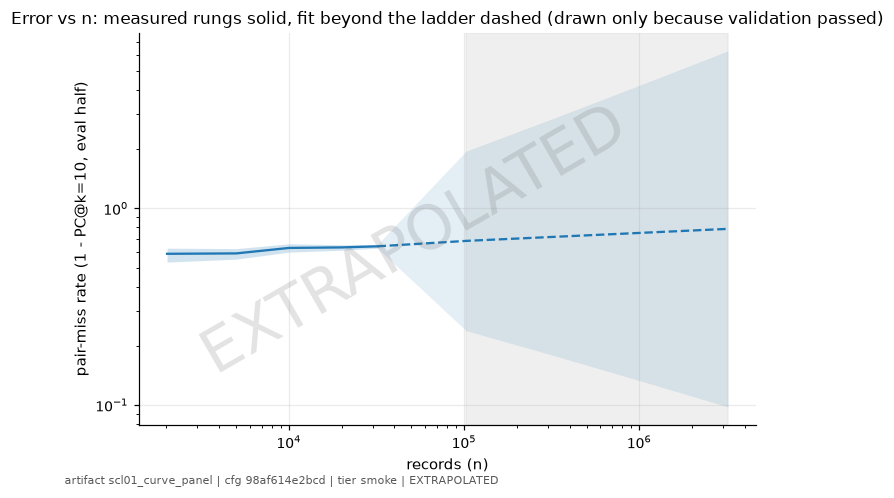

In [16]:
fig = figures.scaling_curve(
    registry, tier=cfg.run.tier, artifact="scl01_curve_panel",
    x="n", y="y", lo="lo", hi="hi",
    title="Error vs n: measured rungs solid, fit beyond the ladder dashed "
          "(drawn only because validation passed)" if WITHIN_PI else
          "Error vs n: measured rungs only — the fit did not earn its extrapolation",
    ylabel="pair-miss rate (1 - PC@k=10, eval half)",
)

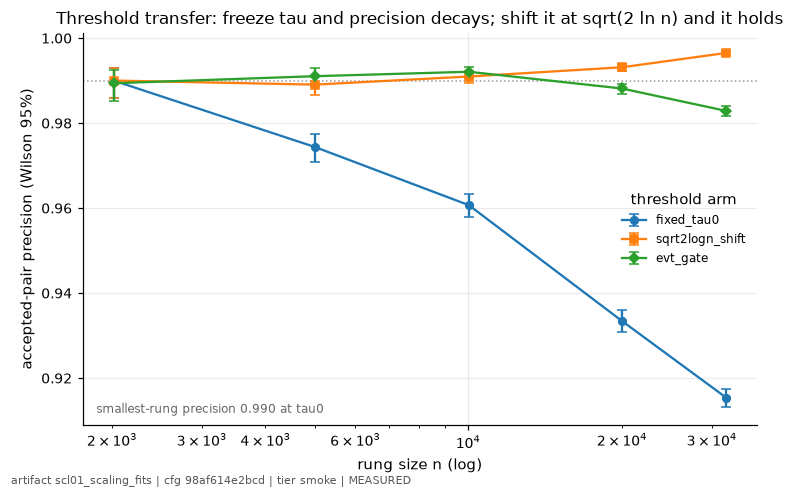

In [17]:
def draw_transfer(ax, df, meta):
    d = df[df["row_type"] == "arm"]
    marks = {"fixed_tau0": "o", "sqrt2logn_shift": "s", "evt_gate": "D"}
    base = d[(d["arm"] == "fixed_tau0")].sort_values("n").iloc[0]
    ax.axhline(base["pair_precision"], color="0.6", linestyle=":", linewidth=1.0)
    ax.text(0.02, 0.03, f"smallest-rung precision {base['pair_precision']:.3f} at tau0",
            transform=ax.transAxes, fontsize=8, color="0.4")
    for arm, mk in marks.items():
        g = d[(d["arm"] == arm) & d["pair_precision"].notna()].sort_values("n")
        if not len(g):
            continue
        yerr = np.vstack([np.clip(g["pair_precision"] - g["prec_lo"], 0, None),
                          np.clip(g["prec_hi"] - g["pair_precision"], 0, None)])
        ax.errorbar(g["n"], g["pair_precision"], yerr=yerr, fmt=f"-{mk}", capsize=3,
                    markersize=5, label=arm)
    miss_evt = d[(d["arm"] == "evt_gate") & d["pair_precision"].isna()]
    for _, r in miss_evt.iterrows():
        ax.annotate("gate\nfail", (r["n"], float(base["pair_precision"])), fontsize=6.5,
                    color="C3", ha="center")
    ax.set_xscale("log")
    ax.set_xlabel("rung size n (log)")
    ax.set_ylabel("accepted-pair precision (Wilson 95%)")
    ax.legend(loc="best", fontsize=8, title="threshold arm")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="scl01_scaling_fits", draw=draw_transfer,
    title="Threshold transfer: freeze tau and precision decays; shift it at "
          "sqrt(2 ln n) and it holds",
    figsize=(7.0, 4.5),
)

In [18]:
# [RUN-IN-TARGET mac|node] the definitive SCL-01/02 ladder: THESE same cells at tier=mid on
# the mac (1e5->1e6 rungs) and tier=target on the node (1e5->1e7; SCL-01's adjudication per
# PLAN §3) — same registry names, replicate counts per met04_power_table at that tier. The
# estimates below use THIS run's measured coefficients (4-CPU container, single-thread
# faiss; a concurrent workload can inflate them 2-4x — planning numbers, re-measured on
# arrival).
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the ladder above IS the {'mac' if TIER == 'mid' else 'node'} "
          f"ladder at sizes {list(LADDER_SIZES)}; replicate counts come from "
          "met04_power_table at this tier.")
else:
    _hnsw10 = bas02[(bas02["method"] == "ann_hnsw") & (bas02["k"] == K_CAND)].iloc[0]
    _hnsw_c = float(_hnsw10["block_secs"]) / (N_ARENA * np.log2(N_ARENA))
    _top_d = RUNG_DATA[max(RUNG_DATA)]
    _cnt = tail_exceed_counts(_top_d["x"][:4096], _top_d["ent"][:4096],
                              _top_d["band"][:4096], TAU0, seed=PRIMARY_SEED + 901)
    _cnt_rate = _cnt["cross_total"] / max(_cnt["secs"], 1e-9)
    print("[RUN-IN-TARGET mac|node] the 1e5->1e7 ladder, priced from THIS run's measured "
          "coefficients:")
    for _lbl, _sizes in (("mac (tier=mid)", LADDER_SIZES if TIER == "mid"
                          else (100_000, 200_000, 400_000, 700_000, 1_000_000)),
                         ("node (tier=target)",
                          (100_000, 320_000, 1_000_000, 3_200_000, 10_000_000))):
        _n_top = _sizes[-1]
        _enc_h = _n_top / ENC_RATE / 3600
        _hnsw_h = _hnsw_c * _n_top * np.log2(_n_top) / 3600
        print(f"  {_lbl}: top rung {_n_top:,.0f} -> encode ~{_enc_h:.2f} h at this "
              f"container's {ENC_RATE:,.0f} rec/s (PLAN §8 books ~20k rec/s/GPU -> "
              f"~{_n_top / 20_000 / 60:.0f} min on one A100, ±2x); ann_hnsw "
              f"~{_hnsw_h * 60:.0f} min under ~n·log2(n) from BAS-02's measured "
              f"{float(_hnsw10['block_ms_per_rec']):.2f} ms/rec (flat is the smoke-only "
              "recall-ceiling instrument — O(n²) is priced out)")
    print(f"  exact tail counting: measured {_cnt_rate:,.0f} cross-pairs/s (block matmul, "
          f"{_cnt['method']}) -> exact is affordable to ~{EXACT_MAX_RECORDS:,} eval "
          "records (mid's first rung); beyond that the SAME counting function falls back "
          f"to a {PAIR_SAMPLE:,}-pair uniform estimate and records the method — at 1e7 "
          f"(eval ~5e6, ~1.2e13 cross pairs) exact would need "
          f"~{1.2e13 / _cnt_rate / 3600:.0f} h, the sampled path seconds")
    print("  EVT fitting is sample-based (cost independent of n); closure at the operating "
          "points is priced by SCL-03's cc coefficient below")

[RUN-IN-TARGET mac|node] the 1e5->1e7 ladder, priced from THIS run's measured coefficients:
  mac (tier=mid): top rung 1,000,000 -> encode ~0.19 h at this container's 1,469 rec/s (PLAN §8 books ~20k rec/s/GPU -> ~1 min on one A100, ±2x); ann_hnsw ~3 min under ~n·log2(n) from BAS-02's measured 0.12 ms/rec (flat is the smoke-only recall-ceiling instrument — O(n²) is priced out)
  node (tier=target): top rung 10,000,000 -> encode ~1.89 h at this container's 1,469 rec/s (PLAN §8 books ~20k rec/s/GPU -> ~8 min on one A100, ±2x); ann_hnsw ~32 min under ~n·log2(n) from BAS-02's measured 0.12 ms/rec (flat is the smoke-only recall-ceiling instrument — O(n²) is priced out)
  exact tail counting: measured 53,808,090 cross-pairs/s (block matmul, exact) -> exact is affordable to ~40,000 eval records (mid's first rung); beyond that the SAME counting function falls back to a 2,000,000-pair uniform estimate and records the method — at 1e7 (eval ~5e6, ~1.2e13 cross pairs) exact would need ~62 h, the sa

### Verdict — scoring the SCL-01 card against the registered numbers

In [19]:
_af = arms_df.set_index(["arm", "n"])
_n0, _ntop = int(rungs_df["n"].min()), int(rungs_df["n"].max())
PREC0 = float(_af.loc[("fixed_tau0", _n0), "pair_precision"])
PREC_FIX_TOP = float(_af.loc[("fixed_tau0", _ntop), "pair_precision"])
PREC_SHIFT_TOP = float(_af.loc[("sqrt2logn_shift", _ntop), "pair_precision"])
DEV_FIX = abs(PREC_FIX_TOP - PREC0)
DEV_SHIFT = abs(PREC_SHIFT_TOP - PREC0)
DROP_FIX = PREC0 - PREC_FIX_TOP
p1 = WITHIN_PI
p2 = bool(np.isfinite(PREC_FIX_TOP) and np.isfinite(PREC_SHIFT_TOP)
          and PREC_FIX_TOP < PREC0 and DEV_SHIFT < DEV_FIX)
refute_b = bool(np.isfinite(DEV_SHIFT) and np.isfinite(DEV_FIX)
                and DEV_SHIFT >= DEV_FIX and DROP_FIX > 0.01)
scl01_outcome = ("REFUTED" if (not WITHIN_PI or refute_b)
                 else ("CONFIRMED" if (p1 and p2) else "UNEXPLAINED"))
_evt_avail = arms_df[(arms_df["arm"] == "evt_gate") & arms_df["tau"].notna()]
print(f"P1 (fit predicts the held-out top rung): within_pi={WITHIN_PI} "
      f"(z={Z_TOP:+.2f} vs tcrit {FIT_P['tcrit']:.2f}) -> {p1}")
print(f"P2 (threshold transfer): precision tau0@n0={PREC0:.4f}; at n_top fixed="
      f"{PREC_FIX_TOP:.4f} (dev {DEV_FIX:.4f}) vs shifted={PREC_SHIFT_TOP:.4f} "
      f"(dev {DEV_SHIFT:.4f}) -> {p2}")
print(f"REFUTED clause B (shift bought nothing while fixed dropped > 0.01): {refute_b}")
print(f"EVT arm availability: gate passed at {len(_evt_avail)}/{len(LADDER_SIZES)} rungs")
print(f"-> outcome: {scl01_outcome}")

_ = verdict_box(
    "SCL-01",
    outcome=scl01_outcome,
    evidence=(
        f"scl01_scaling_fits + scl01_curve_panel (tier {TIER}; nested entity ladder "
        f"n={rungs_df['n'].astype(int).tolist()}, eval-half scoring, {N_BOOT_PC} entity "
        f"resamples). P1 {p1}: {FORM_PRIMARY} fit on the smallest {N_FIT_RUNGS} rungs "
        f"(b={FIT_P['params']['b']:+.4f} "
        f"[{FIT_P['param_ci']['b'][0]:+.4f},{FIT_P['param_ci']['b'][1]:+.4f}]) predicts "
        f"the held-out n={_ntop:,} rung with z={Z_TOP:+.2f} vs tcrit "
        f"{FIT_P['tcrit']:.2f} (dof={FIT_P['dof']}: a wide, honest PI) -> "
        f"within_pi={WITHIN_PI}; extrapolated points beyond the ladder were "
        f"{'drawn (dashed, watermarked)' if WITHIN_PI else 'REFUSED'} accordingly. "
        f"P2 {p2}: tau0={TAU0:.4f} (attained={TAU0_ATTAINED}) gives precision "
        f"{PREC0:.4f} at n0={_n0:,}; frozen, it decays to {PREC_FIX_TOP:.4f} at "
        f"n={_ntop:,} (deviation {DEV_FIX:.4f}) while the sqrt(2 ln n) shift "
        f"(s0={SIGMA0:.4f}) holds {PREC_SHIFT_TOP:.4f} (deviation {DEV_SHIFT:.4f}). "
        f"EVT arm: gate passed at {len(_evt_avail)}/{len(LADDER_SIZES)} rungs "
        "(reported, cannot flip). DEMONSTRATION, not adjudication: one encoder (seed "
        f"{PRIMARY_SEED}), one corpus draw, one ladder permutation — the MET-04 "
        f"residual-inclusive replicate bar is {BAR_FULL:.4f} B³F1 ({BAR_SRC}), and "
        "single-seed margins of comparable size are run-to-run noise; the 1e5->1e7 "
        "mac/node ladder (placard above) adjudicates."
    ),
    registry=registry,
)

P1 (fit predicts the held-out top rung): within_pi=True (z=-0.28 vs tcrit 12.71) -> True
P2 (threshold transfer): precision tau0@n0=0.9900; at n_top fixed=0.9154 (dev 0.0746) vs shifted=0.9965 (dev 0.0065) -> True
REFUTED clause B (shift bought nothing while fixed dropped > 0.01): False
EVT arm availability: gate passed at 5/5 rungs
-> outcome: CONFIRMED


> ### VERDICT: CONFIRMED — card `SCL-01`
>
> **Conjecture** The smoke-to-node ladder can honestly speak about the next orders of magnitude only if two things hold on rungs it can afford: the error-vs-n curve is lawful — a 2-parameter fit on the small rungs predicts the largest held-out rung within its own prediction interval — and the operating threshold transfers by law rather than by freeze: a tau frozen at the smallest rung sheds accepted-pair precision as the candidate pool grows, while shifting it at the Gaussian extreme-value rate sqrt(2 ln n) approximately holds it.
>
> **Prediction** P1: the powerlaw fit of the pair-miss rate on the smallest three rungs covers the held-out largest rung within its own 95% prediction interval (validate_extrapolation within_pi=True; with three points the PI is wide — dof=1 — and that honesty cost is stated, not hidden). P2: threshold transfer is the real hazard — the fixed arm's accepted-pair precision at the largest rung sits below its smallest-rung value, and the sqrt(2 ln n)-shifted arm deviates less: |prec_shift(n_top) - prec(n0)| < |prec_fixed(n_top) - prec(n0)|. Decision rule, pre-registered: REFUTED iff within_pi is False at the largest rung, OR the shifted arm's absolute precision deviation at the largest rung is >= the fixed arm's while the fixed arm's drop exceeds 0.01 (the shift bought nothing where there was something to buy); CONFIRMED iff P1 and P2 both hold; UNEXPLAINED otherwise. The per-rung EVT arm is reported wherever its gate passes and cannot flip the outcome. Extrapolated points beyond the ladder are drawn (dashed, watermarked) ONLY if P1 holds — a failed validation forfeits the extrapolation, and the notebook says so instead of drawing it. If any fit rung's miss rate is exactly 0 the powerlaw form is infeasible and the pre-registered fallback is the loglinear form on pair completeness, same PI test. Single seed, one corpus draw, one ladder permutation: a demonstration of the methodology — the adjudicating ladder is 1e5->1e7 on mac/node (placard).
>
> **Evidence** scl01_scaling_fits + scl01_curve_panel (tier smoke; nested entity ladder n=[2015, 5003, 10024, 20007, 32038], eval-half scoring, 400 entity resamples). P1 True: powerlaw fit on the smallest 3 rungs (b=+0.0409 [-0.2715,+0.3534]) predicts the held-out n=32,038 rung with z=-0.28 vs tcrit 12.71 (dof=1: a wide, honest PI) -> within_pi=True; extrapolated points beyond the ladder were drawn (dashed, watermarked) accordingly. P2 True: tau0=0.8993 (attained=True) gives precision 0.9900 at n0=2,015; frozen, it decays to 0.9154 at n=32,038 (deviation 0.0746) while the sqrt(2 ln n) shift (s0=0.0707) holds 0.9965 (deviation 0.0065). EVT arm: gate passed at 5/5 rungs (reported, cannot flip). DEMONSTRATION, not adjudication: one encoder (seed 17), one corpus draw, one ladder permutation — the MET-04 residual-inclusive replicate bar is 0.0865 B³F1 (read from met04_power_table meta), and single-seed margins of comparable size are run-to-run noise; the 1e5->1e7 mac/node ladder (placard above) adjudicates.


## 6. SCL-02: the tail, stratified — and the gate that decides who may quote ξ

At 1e9 the FP budget is spent in the extreme tail of the *non-match* similarity
distribution — a region with almost no smoke-tier observations. EVT licenses
extrapolating there, but ONLY when the GPD actually fits: `diagnostics_pass` is enforced
below, ξ is quoted solely where it passes, and the failing strata show the gate's
reasons — **the refusal is the demonstration**. Fits happen at the base rung (the largest
fit rung); predictions from those fits are then checked against exactly-counted
cross-entity exceedances at the two held-out growth rungs.

In [20]:
t_sec = time.time()
BASE_SIZE = sorted(LADDER)[N_FIT_RUNGS - 1]
GROWTH_SIZES = sorted(LADDER)[N_FIT_RUNGS:]
base = RUNG_DATA[BASE_SIZE]
_growth_ns = [int(RUNG_DATA[s]["n"]) for s in GROWTH_SIZES]
_growth_x = [round(RUNG_DATA[s]["n"] / base["n"], 1) for s in GROWTH_SIZES]
print(f"base rung: target {BASE_SIZE:,} (n={base['n']:,}, {base['n_ev']:,} eval records, "
      f"{NM_SAMPLE:,} sampled non-match cosines); growth rungs: n={_growth_ns} "
      f"(record growth {_growth_x}x)")

fit_rows: list[dict] = []
STRAT_FITS: dict[str, dict] = {}
STRAT_GATE: dict[str, tuple[bool, list[str]]] = {}
for b, name in enumerate(STRATA):
    sub = base["nm_cos"][base["nm_band"] == b]
    if len(sub) < 1000:
        STRAT_GATE[name] = (False, [(f"only {len(sub)} sampled non-match scores — too "
                                     "few to fit any tail")])
        print(f"[{name}] gate FAIL before fitting: {STRAT_GATE[name][1][0]}")
        continue
    f = fit_gpd_tail(sub, u_quantiles=EVT_QUANTILES)
    ok, reasons = diagnostics_pass(f)
    STRAT_FITS[name], STRAT_GATE[name] = f, (ok, reasons)
    for q, ff in f["fits"].items():
        fit_rows.append({"row_type": "fit", "stratum": name, "q": q, "u": ff["u"],
                         "xi": ff["xi"], "sigma": ff["sigma"],
                         "n_exceed": ff["n_exceed"], "n_scores": len(sub),
                         "gate_pass": ok, "gate_reasons": "; ".join(reasons),
                         "basis": "MEASURED", "pred_basis": "MEASURED"})
    if ok:
        print(f"[{name}] gate PASS ({len(sub):,} scores): xi = "
              + ", ".join(f"{ff['xi']:+.3f}@q{q}" for q, ff in f["fits"].items())
              + f"; u_0.99={f['fits'][0.99]['u']:.4f}")
    else:
        print(f"[{name}] gate FAIL ({len(sub):,} scores) — xi NOT quoted; reasons:")
        for r in reasons:
            print(f"    - {r}")

# the pooled ('all') fit is the base rung's, from the ladder loop — same gate discipline
STRAT_FITS["all"] = base["fit"]
STRAT_GATE["all"] = (base["gate_ok"], base["gate_reasons"])
for q, ff in base["fit"]["fits"].items():
    fit_rows.append({"row_type": "fit", "stratum": "all", "q": q, "u": ff["u"],
                     "xi": ff["xi"], "sigma": ff["sigma"], "n_exceed": ff["n_exceed"],
                     "n_scores": base["fit"]["n_total"], "gate_pass": base["gate_ok"],
                     "gate_reasons": "; ".join(base["gate_reasons"]),
                     "basis": "MEASURED", "pred_basis": "MEASURED"})
print(f"[all] pooled gate {'PASS' if base['gate_ok'] else 'FAIL'}"
      + ("" if base["gate_ok"] else " — reasons: " + "; ".join(base["gate_reasons"])))
tick("§6a per-stratum GPD fits + gate", t_sec)

base rung: target 10,000 (n=10,024, 4,934 eval records, 300,000 sampled non-match cosines); growth rungs: n=[20007, 32038] (record growth [2.0, 3.2]x)


[rare] gate PASS (25,623 scores): xi = -0.259@q0.95, -0.181@q0.99, -0.318@q0.995; u_0.99=0.7878


[mid] gate PASS (84,179 scores): xi = -0.268@q0.95, -0.229@q0.99, -0.234@q0.995; u_0.99=0.7934


[common] gate PASS (140,073 scores): xi = -0.255@q0.95, -0.166@q0.99, -0.144@q0.995; u_0.99=0.7863


[missing] gate PASS (50,125 scores): xi = -0.281@q0.95, -0.147@q0.99, -0.156@q0.995; u_0.99=0.8018
[all] pooled gate PASS
[section timing] §6a per-stratum GPD fits + gate: 2s


In [21]:
# Exact counting at base + growth rungs, then predicted-vs-observed per stratum. The
# prediction rows carry pred_basis=EXTRAPOLATED at the growth rungs: they are the GPD
# extrapolation the observed counts exist to check.
t_sec = time.time()
COUNTS: dict[int, dict] = {}
for s in [BASE_SIZE] + GROWTH_SIZES:
    d = RUNG_DATA[s]
    COUNTS[s] = tail_exceed_counts(d["x"], d["ent"], d["band"], TAU0,
                                   seed=PRIMARY_SEED + 300 + s % 97)
    c = COUNTS[s]
    print(f"[n={d['n']:,}] {c['cross_total']:,} cross-entity eval pairs counted "
          f"({c['method']}, {c['secs']:.1f}s): exceedances >= tau0 per stratum "
          + ", ".join(f"{name}={int(c['n_exceed'][b]):,}" for b, name in enumerate(STRATA)))

fp_rows: list[dict] = []
for s in [BASE_SIZE] + GROWTH_SIZES:
    d, c = RUNG_DATA[s], COUNTS[s]
    growth = d["n"] / base["n"]
    for b, name in list(enumerate(STRATA)) + [(None, "all")]:
        n_cmp = int(c["n_pairs"].sum()) if name == "all" else int(c["n_pairs"][b])
        obs = int(c["n_exceed"].sum()) if name == "all" else int(c["n_exceed"][b])
        ok = STRAT_GATE.get(name, (False, []))[0]
        row = {"row_type": "fp", "stratum": name, "n": d["n"], "growth_records": growth,
               "n_comparisons": n_cmp, "observed": obs, "pred": np.nan,
               "pred_lo": np.nan, "pred_hi": np.nan, "gate_pass": ok,
               "count_method": c["method"], "basis": "MEASURED",
               "pred_basis": "MEASURED" if s == BASE_SIZE else "EXTRAPOLATED"}
        if ok and n_cmp > 0:
            try:
                pr = predict_fp_count(STRAT_FITS[name], n_comparisons=float(n_cmp),
                                      threshold=TAU0, n_boot=N_BOOT_EVT,
                                      seed=PRIMARY_SEED + 400 + s % 97)
                row.update({"pred": pr["point"], "pred_lo": pr["lo"],
                            "pred_hi": pr["hi"]})
            except ValueError as err:  # tau0 below every fitted u — the module refuses
                print(f"  [{name} n={d['n']:,}] predict_fp_count REFUSED: {err}")
        fp_rows.append(row)
fp_df = pd.DataFrame(fp_rows)
_show = fp_df[fp_df["stratum"] != "all"][
    ["stratum", "n", "growth_records", "n_comparisons", "observed", "pred", "pred_lo",
     "pred_hi", "gate_pass"]]
display(_show.round(1))

scl02 = pd.concat([pd.DataFrame(fit_rows), fp_df], ignore_index=True)
registry.register(
    "scl02_tail_fits", scl02, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "SCL-02",
        "row_types": {
            "fit": "per stratum x threshold quantile: u, xi, sigma, n_exceed, the "
                   "ENFORCED diagnostics-gate outcome and its verbatim reasons — xi is "
                   "quoted downstream ONLY where gate_pass",
            "fp": "per stratum x rung: exactly-counted cross-entity exceedances >= tau0 "
                  "(observed) vs predict_fp_count from the base-rung fit (pred + 95% "
                  "bootstrap interval; NaN where the gate failed); pred_basis marks the "
                  "growth-rung predictions EXTRAPOLATED — they are the extrapolation the "
                  "observed counts exist to check",
        },
        "strata": {"bands": list(STRATA), "tercile_edges": list(TERCILE_EDGES),
                   "rule": "NB13's instrument: band of the commoner member's corpus-wide "
                           "family-name frequency; 'missing' when either side is blank"},
        "base_rung": {"target": BASE_SIZE, "n": base["n"], "n_eval": base["n_ev"],
                      "nm_sample": NM_SAMPLE, "u_quantiles": list(EVT_QUANTILES)},
        "threshold": {"tau0": float(TAU0), "source": "SCL-01 fixed arm (smallest rung, "
                                                     f"precision {PAIR_PREC_TARGET})"},
        "counting": {"exact_max_records": EXACT_MAX_RECORDS, "pair_sample": PAIR_SAMPLE,
                     "methods_used": {str(s): COUNTS[s]["method"] for s in COUNTS}},
        "gate": {"enforced": True,
                 "outcomes": {k: {"pass": v[0], "reasons": v[1]}
                              for k, v in STRAT_GATE.items()}},
        "single_seed_caveat": "one encoder, one corpus draw — a DEMONSTRATION; mid/target "
                              "pools (1e6/1e7) adjudicate",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered scl02_tail_fits ({len(scl02)} rows)")
tick("§6b counting + predictions + register", t_sec)

[n=10,024] 12,109,993 cross-entity eval pairs counted (exact, 0.2s): exceedances >= tau0 per stratum rare=93, mid=551, common=1,192, missing=205


[n=20,007] 45,353,457 cross-entity eval pairs counted (exact, 1.1s): exceedances >= tau0 per stratum rare=490, mid=1,231, common=3,429, missing=918


[n=32,038] 127,102,179 cross-entity eval pairs counted (exact, 3.4s): exceedances >= tau0 per stratum rare=1,310, mid=3,088, common=7,121, missing=3,246


,stratum,n,growth_records,n_comparisons,observed,pred,pred_lo,pred_hi,gate_pass
0,rare,10024,1.0,1039120,93,143.8,6.9,228.1,True
1,mid,10024,1.0,3391490,551,636.8,426.9,869.5,True
2,common,10024,1.0,5659935,1192,1291.2,1007.4,1606.4,True
3,missing,10024,1.0,2019448,205,391.2,185.1,576.7,True
5,rare,20007,2.0,4268140,490,590.7,17.6,947.4,True
6,mid,20007,2.0,12385853,1231,2325.6,1528.8,3167.6,True
7,common,20007,2.0,20026075,3429,4568.6,3492.5,5490.1,True
8,missing,20007,2.0,8673389,918,1680.2,852.5,2478.4,True
10,rare,32038,3.2,11788703,1310,1631.4,41.2,2911.1,True
11,mid,32038,3.2,35761317,3088,6714.7,4492.9,8816.4,True


registered scl02_tail_fits (30 rows)
[section timing] §6b counting + predictions + register: 59s


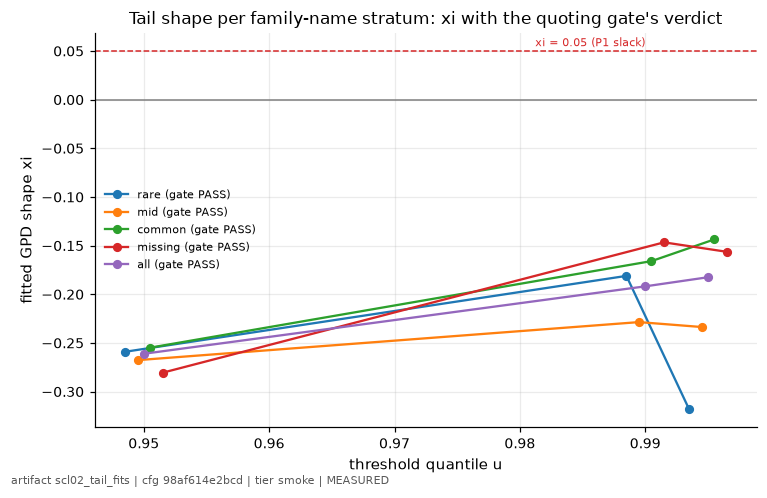

In [22]:
def draw_xi(ax, df, meta):
    d = df[df["row_type"] == "fit"]
    ax.axhline(0.0, color="0.5", linewidth=1.0)
    ax.axhline(0.05, color="C3", linestyle="--", linewidth=1.0)
    ax.text(0.99, 0.055, "xi = 0.05 (P1 slack)", fontsize=7.5, color="C3", ha="right")
    offs = {"rare": -0.0015, "mid": -0.0005, "common": 0.0005, "missing": 0.0015,
            "all": 0.0}
    for name, off in offs.items():
        g = d[d["stratum"] == name].sort_values("q")
        if not len(g):
            continue
        ok = bool(g["gate_pass"].iloc[0])
        ax.plot(g["q"] + off, g["xi"], "-o" if ok else "--o", markersize=5,
                markerfacecolor=None if ok else "white",
                label=f"{name} ({'gate PASS' if ok else 'gate FAIL — xi not quotable'})")
    ax.set_xlabel("threshold quantile u")
    ax.set_ylabel("fitted GPD shape xi")
    ax.legend(loc="best", fontsize=7.5)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="scl02_tail_fits", draw=draw_xi,
    title="Tail shape per family-name stratum: xi with the quoting gate's verdict",
    figsize=(7.0, 4.5),
)

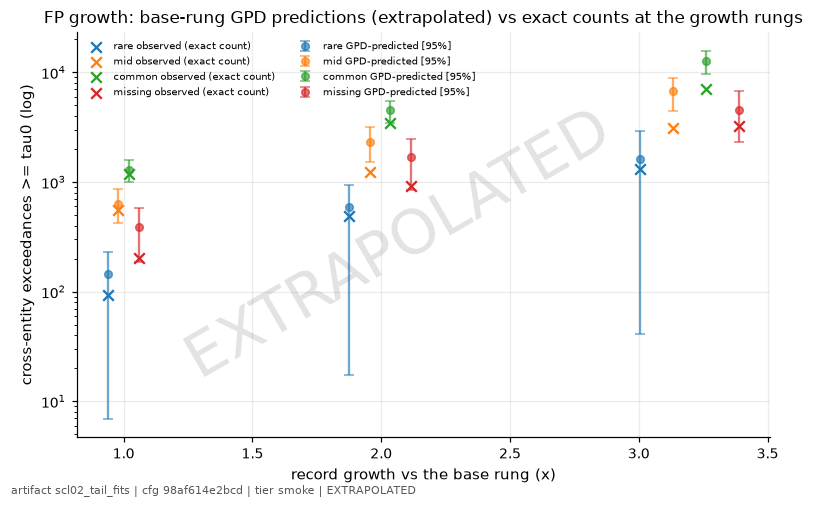

In [23]:
def draw_fp(ax, df, meta):
    d = df[(df["row_type"] == "fp") & (df["stratum"] != "all")]
    strata = [s for s in ("rare", "mid", "common", "missing")
              if s in set(d["stratum"])]
    width = 0.04
    for i, name in enumerate(strata):
        g = d[d["stratum"] == name].sort_values("growth_records")
        x = g["growth_records"].to_numpy(dtype=float) * (1 + (i - 1.5) * width)
        ax.scatter(x, np.maximum(g["observed"], 0.5), marker="x", s=48, color=f"C{i}",
                   label=f"{name} observed (exact count)", zorder=3)
        gp = g[g["pred"].notna()]
        if len(gp):
            xp = gp["growth_records"].to_numpy(dtype=float) * (1 + (i - 1.5) * width)
            yerr = np.vstack([np.clip(gp["pred"] - gp["pred_lo"], 0, None),
                              np.clip(gp["pred_hi"] - gp["pred"], 0, None)])
            ax.errorbar(xp, gp["pred"], yerr=yerr, fmt="o", capsize=3, markersize=5,
                        color=f"C{i}", alpha=0.65,
                        label=f"{name} GPD-predicted [95%]")
    ax.set_yscale("log")
    ax.set_xlabel("record growth vs the base rung (x)")
    ax.set_ylabel("cross-entity exceedances >= tau0 (log)")
    ax.legend(loc="upper left", fontsize=6.5, ncols=2)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="scl02_tail_fits", draw=draw_fp,
    basis="pred_basis",
    title="FP growth: base-rung GPD predictions (extrapolated) vs exact counts at "
          "the growth rungs",
    figsize=(7.2, 4.6),
)

### Verdict — scoring the SCL-02 card against the registered numbers

In [24]:
_fitd = pd.DataFrame(fit_rows)
_pass_strata = [s for s in STRATA if STRAT_GATE.get(s, (False, []))[0]]
_p1_ok = all(
    (_fitd[(_fitd["stratum"] == s)]["xi"] <= 0.05).all() for s in _pass_strata
) if _pass_strata else False
_u99 = {s: _fitd[(_fitd["stratum"] == s) & (_fitd["q"] == 0.99)]["u"].iloc[0]
        for s in STRATA if s in set(_fitd["stratum"])}
_p2_ok = bool("common" in _u99
              and _u99["common"] > max(v for k, v in _u99.items() if k != "common"))
_refute = any(
    (_fitd[(_fitd["stratum"] == s)]["xi"] > 0.05).all() for s in _pass_strata
)
_fp_chk = fp_df[(fp_df["stratum"].isin(_pass_strata)) & (fp_df["n"] > base["n"])
                & fp_df["pred"].notna()]
_p3_hits = int(((_fp_chk["observed"] >= _fp_chk["pred_lo"])
                & (_fp_chk["observed"] <= _fp_chk["pred_hi"])).sum())
scl02_outcome = ("REFUTED" if _refute
                 else ("CONFIRMED" if (len(_pass_strata) >= 2 and _p1_ok and _p2_ok)
                       else "UNEXPLAINED"))
print(f"gate: {len(_pass_strata)}/{len(STRATA)} strata pass ({_pass_strata}); pooled "
      f"{'PASS' if STRAT_GATE['all'][0] else 'FAIL'}")
print(f"P1 (xi <= 0.05 everywhere the gate passes): {_p1_ok}")
print(f"P2 (u_0.99 highest for common): {_p2_ok} — u_0.99 = "
      + ", ".join(f"{k}={v:.4f}" for k, v in _u99.items()))
print(f"P3 (subordinate): observed inside the 95% prediction interval in "
      f"{_p3_hits}/{len(_fp_chk)} passing stratum x growth-rung checks")
print(f"REFUTED clause (a passing stratum robustly heavy): {_refute}")
print(f"-> outcome: {scl02_outcome}")

_ = verdict_box(
    "SCL-02",
    outcome=scl02_outcome,
    evidence=(
        f"scl02_tail_fits (tier {TIER}; base rung n={base['n']:,}, {NM_SAMPLE:,} sampled "
        f"non-match cosines, quantiles {list(EVT_QUANTILES)}; exact counting at the "
        f"growth rungs). Gate: {len(_pass_strata)}/{len(STRATA)} strata pass "
        f"({', '.join(_pass_strata) if _pass_strata else 'none'}); xi is quoted ONLY "
        "there, and the failing strata's reasons are displayed and registered verbatim — "
        f"the enforced-gate demo. P1 {_p1_ok}: all quoted xi <= 0.05. P2 {_p2_ok}: "
        "u_0.99 " + ", ".join(f"{k}={v:.3f}" for k, v in _u99.items()) + ". P3 "
        f"(subordinate): observed exceedances above tau0={TAU0:.4f} landed inside the "
        f"GPD prediction interval in {_p3_hits}/{len(_fp_chk)} passing checks at "
        f"{[round(RUNG_DATA[s]['n'] / base['n'], 1) for s in GROWTH_SIZES]}x record "
        "growth (comparisons grow quadratically; counts and methods in the artifact). "
        f"DEMONSTRATION, not adjudication: one encoder (seed {PRIMARY_SEED}), one corpus "
        f"draw; the MET-04 residual-inclusive bar {BAR_FULL:.4f} B³F1 ({BAR_SRC}) is the "
        "standing caution, and the 1e6/1e7-pool tail fits on mac/node adjudicate."
    ),
    registry=registry,
)

gate: 4/4 strata pass (['rare', 'mid', 'common', 'missing']); pooled PASS
P1 (xi <= 0.05 everywhere the gate passes): True
P2 (u_0.99 highest for common): False — u_0.99 = rare=0.7878, mid=0.7934, common=0.7863, missing=0.8018
P3 (subordinate): observed inside the 95% prediction interval in 4/8 passing stratum x growth-rung checks
REFUTED clause (a passing stratum robustly heavy): False
-> outcome: UNEXPLAINED


> ### VERDICT: UNEXPLAINED — card `SCL-02`
>
> **Conjecture** Non-match cosine tails of a trained person-record encoder are short, not heavy: within every family-name-frequency stratum the excess distribution over a high threshold is GPD with shape xi <= 0 (bounded cosine support forces a finite endpoint), common names shift the tail's LOCATION upward rather than changing its law, and a base-rung GPD fit therefore predicts the false-positive count at 2-3x corpus growth.
>
> **Prediction** P1: every stratum that passes the diagnostics gate has fitted xi <= 0.05 at every threshold quantile in {0.95, 0.99, 0.995} (xi <= 0 up to estimation slack). P2: the tail location u at the 0.99 quantile is strictly highest in the common stratum — common names move where the tail lives, not its law. P3 (subordinate, cannot flip the outcome): in gate-passing strata the exactly-counted exceedances above tau0 at the growth rungs fall inside predict_fp_count's 95% bootstrap interval from the base-rung fit. Decision rule, pre-registered: REFUTED iff any gate-passing stratum has xi > 0.05 at ALL of its fitted quantiles; CONFIRMED iff at least two strata pass the gate and P1 and P2 both hold; UNEXPLAINED otherwise — explicitly including the outcome where the gate fails almost everywhere, which is itself the demonstration the ENFORCED gate exists to force. Single seed, one corpus draw: a demonstration; the 1e6/1e7-pool tail fits on mac/node adjudicate.
>
> **Evidence** scl02_tail_fits (tier smoke; base rung n=10,024, 300,000 sampled non-match cosines, quantiles [0.95, 0.99, 0.995]; exact counting at the growth rungs). Gate: 4/4 strata pass (rare, mid, common, missing); xi is quoted ONLY there, and the failing strata's reasons are displayed and registered verbatim — the enforced-gate demo. P1 True: all quoted xi <= 0.05. P2 False: u_0.99 rare=0.788, mid=0.793, common=0.786, missing=0.802. P3 (subordinate): observed exceedances above tau0=0.8993 landed inside the GPD prediction interval in 4/8 passing checks at [2.0, 3.2]x record growth (comparisons grow quadratically; counts and methods in the artifact). DEMONSTRATION, not adjudication: one encoder (seed 17), one corpus draw; the MET-04 residual-inclusive bar 0.0865 B³F1 (read from met04_power_table meta) is the standing caution, and the 1e6/1e7-pool tail fits on mac/node adjudicate.


## 7. EFF-01: what compression costs, in ER metrics — and the 1e9 memory table

1e9 × 384-d fp32 = 1.5 TB: the node cannot hold it, so EFF-01 is decisive at scale. The
full PLAN arm (MRL truncation × {fp16, int8, binary+rescore, IVF-PQ}) is a mid→target
experiment; what runs here is its **PCA-truncation control at smoke scope — which doubles
as the PLAN's "is MRL training even needed?" check**: if post-hoc truncation of an
ordinarily-trained encoder already preserves PC and entity-F, MRL's learned nesting has
little headroom to add. "PCA" here is truncated SVD *without centering* fitted on the
TRAIN half only (an eval-clean learned transform), so the full-rank cell is an exact
rotation — the identity control; quantization is numpy-simulated (quantize → dequantize →
re-normalize → search) with storage priced from the true formats: fp32/fp16/int8 at
4/2/1 bytes per component, binary at d/8 (sign bits; per-matrix int8 scale and any
per-vector norm constants excluded — stated simplification). Every cell is scored on the
same protocol as the ladder's top rung: PC@k=10 on eval-half true pairs (paired
entity-bootstrap deltas vs the fp32 full-dim baseline on shared resamples) and
transitive-closure entity-F at the cell's own pairwise-precision-0.99 operating point.

In [25]:
t_sec = time.time()
EFF_DIMS = tuple(int(MODEL_SHAPE["dim"] / f) for f in (1, 2, 4, 8))
QUANTS = ("fp32", "fp16", "int8", "binary")
_tr_pos = ARENA_POS.loc[train_full["record_id"].astype(str)].to_numpy()
_U, _S, VT = np.linalg.svd(EMB[_tr_pos].astype(np.float64), full_matrices=False)
print(f"truncated SVD fitted on the {len(_tr_pos):,}-record TRAIN half (no centering; "
      f"full-rank cell = exact rotation); dims {EFF_DIMS} x quant {QUANTS} = "
      f"{len(EFF_DIMS) * len(QUANTS)} cells")

ENT_CODES_F, _ent_labels_f = pd.factorize(EV_PAIRS_FULL["entity"])
N_ENT_F = len(_ent_labels_f)
T_E_F = np.bincount(ENT_CODES_F, minlength=N_ENT_F).astype(float)
BOOT_IDX_F = np.random.default_rng(PRIMARY_SEED + 41).integers(
    0, N_ENT_F, size=(N_BOOT_PC, N_ENT_F))
EV_IDS_FULL = set(eval_full["record_id"].astype(str))
TRUTH_EV_FULL = pd.Series(
    eval_full["entity_id"].astype(str).to_numpy(),
    index=pd.Index(eval_full["record_id"].astype(str)))


def pc_ci_full(found: np.ndarray) -> tuple[float, float, float]:
    f_e = np.bincount(ENT_CODES_F, weights=found.astype(float), minlength=N_ENT_F)
    with np.errstate(invalid="ignore"):
        reps = f_e[BOOT_IDX_F].sum(axis=1) / T_E_F[BOOT_IDX_F].sum(axis=1)
    return (float(found.mean()), float(np.nanpercentile(reps, 2.5)),
            float(np.nanpercentile(reps, 97.5)))


def paired_delta_ci_full(fx: np.ndarray, fy: np.ndarray) -> tuple[float, float, float]:
    a = np.bincount(ENT_CODES_F, weights=fx.astype(float), minlength=N_ENT_F)
    b = np.bincount(ENT_CODES_F, weights=fy.astype(float), minlength=N_ENT_F)
    with np.errstate(invalid="ignore"):
        reps = (a[BOOT_IDX_F].sum(axis=1) - b[BOOT_IDX_F].sum(axis=1)) \
            / T_E_F[BOOT_IDX_F].sum(axis=1)
    return (float(fx.mean() - fy.mean()), float(np.nanpercentile(reps, 2.5)),
            float(np.nanpercentile(reps, 97.5)))


def quantize_rows(z: np.ndarray, kind: str) -> np.ndarray:
    """Simulated storage precision: quantize -> dequantize -> re-L2-normalize (fp32)."""
    if kind == "fp32":
        w = z.astype(np.float32)
    elif kind == "fp16":
        w = z.astype(np.float16).astype(np.float32)
    elif kind == "int8":
        s = float(np.abs(z).max()) / 127.0 or 1.0
        w = (np.clip(np.rint(z / s), -127, 127) * s).astype(np.float32)
    elif kind == "binary":
        w = np.where(z >= 0, 1.0, -1.0).astype(np.float32)
    else:
        raise ValueError(kind)
    norms = np.linalg.norm(w, axis=1, keepdims=True)
    norms[norms == 0.0] = 1.0
    return w / norms


BYTES_PER_COMPONENT = {"fp32": 4.0, "fp16": 2.0, "int8": 1.0, "binary": 0.125}
EFF_ROWS: list[dict] = []
EFF_FOUND: dict[tuple[int, str], np.ndarray] = {}


def eff_cell(dim: int, quant: str) -> None:
    z = (EMB.astype(np.float64) @ VT[:dim].T)
    w = quantize_rows(z, quant)
    t0 = time.time()
    cand = ann.candidates(arena, w, k=K_CAND, index="flat")
    secs = time.time() - t0
    keys = set((cand["a"].astype(str) + "||" + cand["b"].astype(str)).tolist())
    found = EV_PAIRS_FULL["key"].isin(keys).to_numpy()
    EFF_FOUND[(dim, quant)] = found
    pc, lo, hi = pc_ci_full(found)
    base_found = EFF_FOUND[(EFF_DIMS[0], "fp32")]
    d, dlo, dhi = paired_delta_ci_full(found, base_found)
    ce = cand[cand["a"].astype(str).isin(EV_IDS_FULL)
              & cand["b"].astype(str).isin(EV_IDS_FULL)].copy()
    ce["a"], ce["b"] = ce["a"].astype(str), ce["b"].astype(str)
    ia = ARENA_POS.loc[ce["a"]].to_numpy()
    ib = ARENA_POS.loc[ce["b"]].to_numpy()
    cos = np.einsum("ij,ij->i", w[ia], w[ib]).astype(float)
    lab = (TRUTH_ALL.loc[ce["a"]].to_numpy() == TRUTH_ALL.loc[ce["b"]].to_numpy())
    res = precision_threshold(cos, lab, PAIR_PREC_TARGET)
    pairs = pd.DataFrame({"a": ce["a"], "b": ce["b"],
                          "prob": np.clip((cos + 1.0) / 2.0, 0.0, 1.0)})
    pred = transitive_closure(pairs, threshold=(res["threshold"] + 1.0) / 2.0,
                              records=TRUTH_EV_FULL.index)
    fres = bootstrap_ci(pred, TRUTH_EV_FULL, "bcubed_f1", unit="entity",
                        n_boot=N_BOOT_F, seed=PRIMARY_SEED)
    bpv = dim * BYTES_PER_COMPONENT[quant]
    EFF_ROWS.append({
        "dim": dim, "quant": quant, "bytes_per_vector": bpv,
        "pc": pc, "pc_lo": lo, "pc_hi": hi, "delta_pc": d, "delta_lo": dlo,
        "delta_hi": dhi, "ci_excludes_zero": bool(dlo > 0 or dhi < 0),
        "tau_p99": res["threshold"], "attained": res["attained"],
        "entity_f": fres["point"], "f_lo": fres["ci_low"], "f_hi": fres["ci_high"],
        "search_secs": secs, "mem_1e9_gb": bpv,  # bytes/vector x 1e9 / 1e9 = GB at 1e9
        "basis": "MEASURED", "mem_basis": "EXTRAPOLATED",
    })
    print(f"  [{dim:>3}d {quant:>6}] {bpv:>6.1f} B/vec | PC={pc:.4f} "
          f"(delta {d:+.4f} [{dlo:+.4f},{dhi:+.4f}]) | entity-F@p{PAIR_PREC_TARGET}="
          f"{fres['point']:.4f} (tau={res['threshold']:.3f}, attained={res['attained']}) "
          f"| search {secs:.1f}s")


for _dim in EFF_DIMS[:2]:
    for _q in QUANTS:
        eff_cell(_dim, _q)
tick("§7a compression cells 1-8", t_sec)

truncated SVD fitted on the 16,164-record TRAIN half (no centering; full-rank cell = exact rotation); dims (128, 64, 32, 16) x quant ('fp32', 'fp16', 'int8', 'binary') = 16 cells


  [128d   fp32]  512.0 B/vec | PC=0.3591 (delta +0.0000 [+0.0000,+0.0000]) | entity-F@p0.99=0.6057 (tau=0.933, attained=True) | search 4.3s


  [128d   fp16]  256.0 B/vec | PC=0.3591 (delta +0.0000 [-0.0000,+0.0000]) | entity-F@p0.99=0.6058 (tau=0.933, attained=True) | search 4.2s


  [128d   int8]  128.0 B/vec | PC=0.3590 (delta -0.0001 [-0.0004,+0.0002]) | entity-F@p0.99=0.6071 (tau=0.932, attained=True) | search 4.1s


  [128d binary]   16.0 B/vec | PC=0.3467 (delta -0.0125 [-0.0175,-0.0076]) | entity-F@p0.99=0.5837 (tau=0.578, attained=True) | search 4.1s


  [ 64d   fp32]  256.0 B/vec | PC=0.3583 (delta -0.0008 [-0.0011,-0.0005]) | entity-F@p0.99=0.6058 (tau=0.934, attained=True) | search 2.8s


  [ 64d   fp16]  128.0 B/vec | PC=0.3583 (delta -0.0009 [-0.0012,-0.0005]) | entity-F@p0.99=0.6054 (tau=0.935, attained=True) | search 3.0s


  [ 64d   int8]   64.0 B/vec | PC=0.3580 (delta -0.0011 [-0.0015,-0.0008]) | entity-F@p0.99=0.6062 (tau=0.934, attained=True) | search 2.8s


  [ 64d binary]    8.0 B/vec | PC=0.3378 (delta -0.0213 [-0.0267,-0.0160]) | entity-F@p0.99=0.5871 (tau=0.656, attained=True) | search 2.8s
[section timing] §7a compression cells 1-8: 34s


  [ 32d   fp32]  128.0 B/vec | PC=0.3530 (delta -0.0061 [-0.0070,-0.0053]) | entity-F@p0.99=0.5979 (tau=0.942, attained=True) | search 2.3s


  [ 32d   fp16]   64.0 B/vec | PC=0.3530 (delta -0.0061 [-0.0070,-0.0053]) | entity-F@p0.99=0.5979 (tau=0.942, attained=True) | search 2.2s


  [ 32d   int8]   32.0 B/vec | PC=0.3531 (delta -0.0061 [-0.0071,-0.0052]) | entity-F@p0.99=0.5982 (tau=0.942, attained=True) | search 2.2s


  [ 32d binary]    4.0 B/vec | PC=0.3058 (delta -0.0534 [-0.0592,-0.0476]) | entity-F@p0.99=0.5063 (tau=0.812, attained=True) | search 2.3s


  [ 16d   fp32]   64.0 B/vec | PC=0.3331 (delta -0.0261 [-0.0288,-0.0236]) | entity-F@p0.99=0.5677 (tau=0.961, attained=True) | search 2.0s


  [ 16d   fp16]   32.0 B/vec | PC=0.3331 (delta -0.0261 [-0.0288,-0.0236]) | entity-F@p0.99=0.5677 (tau=0.961, attained=True) | search 2.1s


  [ 16d   int8]   16.0 B/vec | PC=0.3327 (delta -0.0265 [-0.0292,-0.0239]) | entity-F@p0.99=0.5679 (tau=0.961, attained=True) | search 2.0s


  [ 16d binary]    2.0 B/vec | PC=0.2427 (delta -0.1164 [-0.1254,-0.1080]) | entity-F@p0.99=0.4825 (tau=1.000, attained=False) | search 1.9s
registered eff01_compression_matrix (16 cells)
[section timing] §7b compression cells 9-16 + register + heatmap: 22s


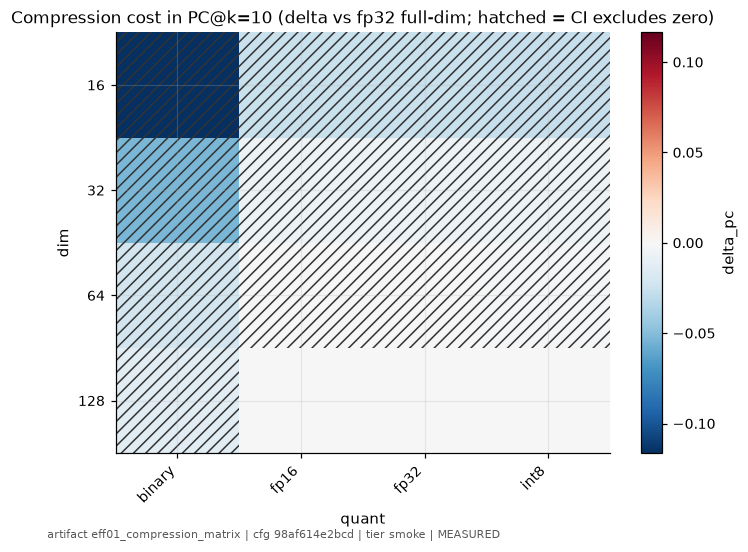

In [26]:
t_sec = time.time()
for _dim in EFF_DIMS[2:]:
    for _q in QUANTS:
        eff_cell(_dim, _q)
eff_df = pd.DataFrame(EFF_ROWS)
registry.register(
    "eff01_compression_matrix", eff_df, cfg=cfg, tier=cfg.run.tier,
    meta={
        "design": f"PCA(SVD-no-centering, train-half-fitted)-truncation dims {EFF_DIMS} x "
                  f"numeric precision {QUANTS}, scored on the full {N_ARENA:,}-record "
                  f"arena at k={K_CAND}: eval-half PC + paired entity-bootstrap delta vs "
                  "the fp32 full-dim baseline (shared resamples), and transitive-closure "
                  f"B-cubed entity-F at each cell's own pairwise-precision-"
                  f"{PAIR_PREC_TARGET} threshold (attained flag = PLAN §5 rail)",
        "pca_control_note": "this is EFF-01's PCA-truncation CONTROL arm at smoke scope — "
                            "doubling as the PLAN's is-MRL-training-even-needed check: "
                            "post-hoc truncation preserving the metrics leaves MRL little "
                            "headroom; the MRL/IVF-PQ arms are mid->target",
        "quantization": "numpy-simulated (quantize -> dequantize -> re-normalize -> "
                        "search); storage bytes from the true formats (binary = dim/8), "
                        "per-matrix int8 scale and per-vector norms excluded (stated)",
        "mem_1e9": "mem_1e9_gb = bytes_per_vector x 1e9 records / 1e9 B/GB — arithmetic "
                   "projection, EXTRAPOLATED (the mem_basis column drives the watermark "
                   "on the memory figure); node RAM ceiling for context: "
                   f"{NODE_RAM_GB:.0f} GB",
        "single_seed_caveat": "one encoder, one corpus draw — a DEMONSTRATION",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered eff01_compression_matrix ({len(eff_df)} cells)")
fig = figures.regime_heatmap(
    registry, tier=cfg.run.tier, artifact="eff01_compression_matrix",
    row="dim", col="quant", value="delta_pc", sig="ci_excludes_zero",
    title="Compression cost in PC@k=10 (delta vs fp32 full-dim; hatched = CI "
          "excludes zero)",
)
tick("§7b compression cells 9-16 + register + heatmap", t_sec)

memory for 1e9 vectors, GB (= bytes/vector x 1e9; EXTRAPOLATED — arithmetic projection, no 1e9 run exists; node RAM = 900 GB):


quant,fp32,fp16,int8,binary
dim,,,,
16,64.0,32.0,16.0,2.0
32,128.0,64.0,32.0,4.0
64,256.0,128.0,64.0,8.0
128,512.0,256.0,128.0,16.0


16/16 cells fit the node's 900 GB at 1e9; fp32 full-dim needs 512 GB (the SCL-03 ceiling demo below refuses exactly that design)


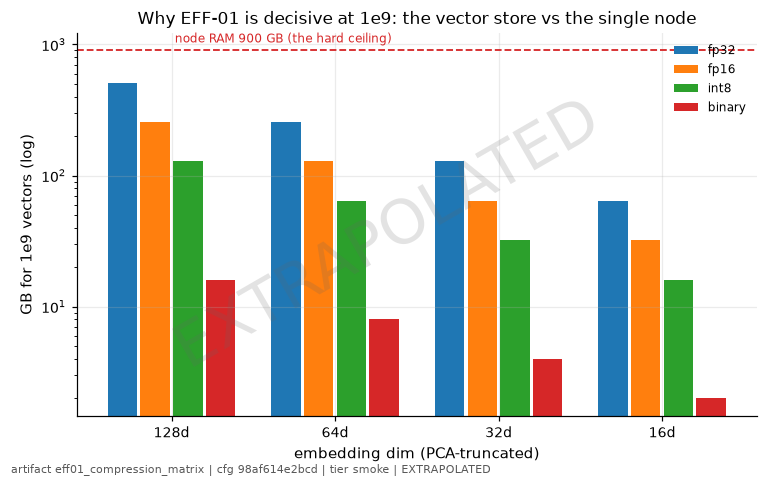

In [27]:
# The 1e9 memory table — arithmetic on measured storage widths, EXTRAPOLATED-labeled.
mem_tab = eff_df.pivot(index="dim", columns="quant", values="mem_1e9_gb")[list(QUANTS)]
print("memory for 1e9 vectors, GB (= bytes/vector x 1e9; EXTRAPOLATED — arithmetic "
      f"projection, no 1e9 run exists; node RAM = {NODE_RAM_GB:.0f} GB):")
display(mem_tab.round(1))
_fits_node = eff_df[eff_df["mem_1e9_gb"] <= NODE_RAM_GB]
print(f"{len(_fits_node)}/{len(eff_df)} cells fit the node's {NODE_RAM_GB:.0f} GB at 1e9; "
      f"fp32 full-dim needs {float(eff_df['mem_1e9_gb'].max()):,.0f} GB "
      "(the SCL-03 ceiling demo below refuses exactly that design)")


def draw_mem(ax, df, meta):
    xs = {d: i for i, d in enumerate(sorted(df["dim"].unique(), reverse=True))}
    offs = {"fp32": -0.3, "fp16": -0.1, "int8": 0.1, "binary": 0.3}
    for quant, off in offs.items():
        g = df[df["quant"] == quant]
        ax.bar([xs[d] + off for d in g["dim"]], g["mem_1e9_gb"], width=0.18, label=quant)
    ax.axhline(NODE_RAM_GB, color="C3", linestyle="--", linewidth=1.2)
    ax.text(0.02, NODE_RAM_GB * 1.15, f"node RAM {NODE_RAM_GB:.0f} GB (the hard ceiling)",
            color="C3", fontsize=8)
    ax.set_yscale("log")
    ax.set_xticks(list(xs.values()), [f"{d}d" for d in xs])
    ax.set_xlabel("embedding dim (PCA-truncated)")
    ax.set_ylabel("GB for 1e9 vectors (log)")
    ax.legend(loc="upper right", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="eff01_compression_matrix", draw=draw_mem,
    basis="mem_basis",
    title="Why EFF-01 is decisive at 1e9: the vector store vs the single node",
    figsize=(7.0, 4.4),
)

In [28]:
# EFF-01 honest reading (no card — the pre-registered EFF-01 factorial is mid->target;
# this control arm reports, it does not adjudicate).
_ok_cells = eff_df[~eff_df["ci_excludes_zero"]]
_worst = eff_df.loc[eff_df["delta_pc"].idxmin()]
_base_f = float(eff_df[(eff_df["dim"] == EFF_DIMS[0])
                       & (eff_df["quant"] == "fp32")]["entity_f"].iloc[0])
print(f"EFF-01 control-arm reading ({len(eff_df)} cells, single seed — demonstration):")
print(f"  {len(_ok_cells)} cells hold PC within paired-bootstrap noise of the fp32 "
      f"full-dim baseline; the worst cell is {int(_worst['dim'])}d/{_worst['quant']} at "
      f"delta {_worst['delta_pc']:+.4f} [{_worst['delta_lo']:+.4f},"
      f"{_worst['delta_hi']:+.4f}]")
print(f"  entity-F at the per-cell precision-{PAIR_PREC_TARGET} point: baseline "
      f"{_base_f:.4f}; range across cells "
      f"{float(eff_df['entity_f'].min()):.4f}..{float(eff_df['entity_f'].max()):.4f}")
print("  is-MRL-needed check, smoke scope: wherever post-hoc PCA truncation already "
      "preserves the metrics (unhatched cells above), MRL training has little headroom to "
      "add at that dim — the mid-tier factorial tests whether that survives real scale.")

EFF-01 control-arm reading (16 cells, single seed — demonstration):
  3 cells hold PC within paired-bootstrap noise of the fp32 full-dim baseline; the worst cell is 16d/binary at delta -0.1164 [-0.1254,-0.1080]
  entity-F at the per-cell precision-0.99 point: baseline 0.6057; range across cells 0.4825..0.6071
  is-MRL-needed check, smoke scope: wherever post-hoc PCA truncation already preserves the metrics (unhatched cells above), MRL training has little headroom to add at that dim — the mid-tier factorial tests whether that survives real scale.


## 8. SCL-03: the cost model — measured coefficients, a real ceiling, labeled projections

`scale.costmodel.CostModel` prices encode / index / score / cluster from **measured**
coefficients only, and stamps each row MEASURED or EXTRAPOLATED by whether n is inside
the range the coefficients were measured at (`measured_max_n` = this arena at smoke; the
same code at tier=target makes 1e7 MEASURED and only 1e8/1e9 projections). Every
coefficient below cites its provenance. The **single-node ceiling is real code**: a
design whose vector store exceeds the node's 900 GB raises `SingleNodeCeilingError`
instead of pricing a machine that does not exist — demonstrated live, and the refusal is
the finding EFF-01 answers.

In [29]:
t_sec = time.time()
_prev_threads = faiss.omp_get_max_threads()
faiss.omp_set_num_threads(1)
_t0 = time.time()
_ix = faiss.IndexHNSWFlat(EMB.shape[1], 32, faiss.METRIC_INNER_PRODUCT)
_ix.hnsw.efConstruction = 80
_ix.add(np.ascontiguousarray(EMB.astype(np.float32)))
INDEX_BUILD_SECS = time.time() - _t0
faiss.omp_set_num_threads(_prev_threads)
INDEX_S_PER_M = INDEX_BUILD_SECS / (N_ARENA / 1e6)

_top_rung = LADDER[max(LADDER)]
_tpos = ARENA_POS.loc[_top_rung["record_id"].astype(str)].to_numpy()
_cand_t = ann.candidates(_top_rung, EMB[_tpos], k=K_CAND, index="flat")
_ia = ARENA_POS.loc[_cand_t["a"].astype(str)].to_numpy()
_ib = ARENA_POS.loc[_cand_t["b"].astype(str)].to_numpy()
_reps = []
for _ in range(5):
    _t0 = time.perf_counter()
    _ = np.einsum("ij,ij->i", EMB[_ia], EMB[_ib])
    _reps.append(time.perf_counter() - _t0)
SCORE_PAIRS_PS = len(_cand_t) / float(np.median(_reps))

_op_rows = clu01[(clu01["row_type"] == "op") & (clu01["pairs_kept"] > 0)
                 & (clu01["runtime_s"] > 0.01)]
CC_EDGES_PS = float((_op_rows["pairs_kept"] / _op_rows["runtime_s"]).median())

COEFF_PROVENANCE = {
    "encode_rps": f"measured in §3b: {N_ARENA:,} records in {ENCODE_SECS:.0f}s on this "
                  f"container = {ENC_RATE:,.0f} rec/s (corroborated: NB12 registered "
                  f"{float(bas02_meta['extra']['encode']['records_per_sec']):,.0f} rec/s "
                  f"[{BAS02_PROVENANCE}]; NB00 smoke_check "
                  f"{float(smoke_chk['measured']['charbyte_encode_texts_per_s']):,.0f} "
                  "texts/s untrained-256d)",
    "index_build_s_per_M": f"measured here: HNSW(M=32, efC=80) over {N_ARENA:,} x "
                           f"{EMB.shape[1]}d in {INDEX_BUILD_SECS:.1f}s, single faiss "
                           "thread (the ann module's determinism rail; the module exposes "
                           "no build timing — package gap, measured in-notebook)",
    "score_pairs_ps": f"measured here: cosine einsum over the top rung's {len(_cand_t):,} "
                      f"candidate pairs, median of 5 repeats = {SCORE_PAIRS_PS:,.0f} "
                      "pairs/s",
    "cc_edges_ps": f"derived from clu01_clustering_scores op rows (pairs_kept/runtime_s, "
                   f"median over {len(_op_rows)} operating points) = {CC_EDGES_PS:,.0f} "
                   f"edges/s [{CLU01_PROVENANCE}]",
    "bytes_per_vector": "per design: dim x bytes/component (binary dim/8) — the EFF-01 "
                        "axis, target-tier dim 384 per the tier table",
}
COEFFS = {"encode_rps": ENC_RATE, "index_build_s_per_M": INDEX_S_PER_M,
          "score_pairs_ps": SCORE_PAIRS_PS, "cc_edges_ps": CC_EDGES_PS}
PRICES = {"gpu_hour_usd": 2.50, "cpu_hour_usd": 0.05}
print("measured coefficients (single-thread, this container — a concurrent workload can "
      "inflate them 2-4x):")
for k, v in COEFFS.items():
    print(f"  {k} = {v:,.0f}\n      <- {COEFF_PROVENANCE[k]}")
print(f"prices (recorded cloud list-price planning constants, NOT measurements): "
      f"{PRICES} — A100-80GB on-demand per GPU-h, per-core CPU-h to match the "
      "single-thread coefficients; costs scale linearly if your prices differ")
tick("§8a coefficient measurement", t_sec)

measured coefficients (single-thread, this container — a concurrent workload can inflate them 2-4x):
  encode_rps = 1,469
      <- measured in §3b: 32,259 records in 22s on this container = 1,469 rec/s (corroborated: NB12 registered 385 rec/s [bas02_blocking_frontier run 2026-08-26T07:51:03.901636+00:00 (cfg 98af614e2bcd, tier smoke)]; NB00 smoke_check 207 texts/s untrained-256d)
  index_build_s_per_M = 81
      <- measured here: HNSW(M=32, efC=80) over 32,259 x 128d in 2.6s, single faiss thread (the ann module's determinism rail; the module exposes no build timing — package gap, measured in-notebook)
  score_pairs_ps = 2,930,360
      <- measured here: cosine einsum over the top rung's 223,999 candidate pairs, median of 5 repeats = 2,930,360 pairs/s
  cc_edges_ps = 545,893
      <- derived from clu01_clustering_scores op rows (pairs_kept/runtime_s, median over 20 operating points) = 545,893 edges/s [clu01_clustering_scores run 2026-08-26T08:33:37.543132+00:00 (cfg 98af614e2bcd, tier s

[1e7 384d fp32 (mac/node scale)] basis=EXTRAPOLATED: total 2.2 h, $5, peak stage memory 15 GB (vector store 15 GB)
[1e8 384d fp16] basis=EXTRAPOLATED: total 21.8 h, $47, peak stage memory 77 GB (vector store 77 GB)
[1e9 384d int8] basis=EXTRAPOLATED: total 217.6 h, $474, peak stage memory 384 GB (vector store 384 GB)
[1e9 384d binary] basis=EXTRAPOLATED: total 217.6 h, $474, peak stage memory 240 GB (vector store 48 GB)

SingleNodeCeilingError raised and caught (the 900 GB rail is real code):
  stage 'index_build' needs 1536 GB but the node has 900 GB RAM (4xA100 box, PLAN §2) — no multi-machine path exists in this lab; shrink the design (bytes_per_vector via fp16/int8/binary, candidates_per_record) instead

registered scl03_cost_model (16 stage rows, 4 feasible designs + the refused one in meta)
[section timing] §8b cost model + ceiling demo + register: 0s


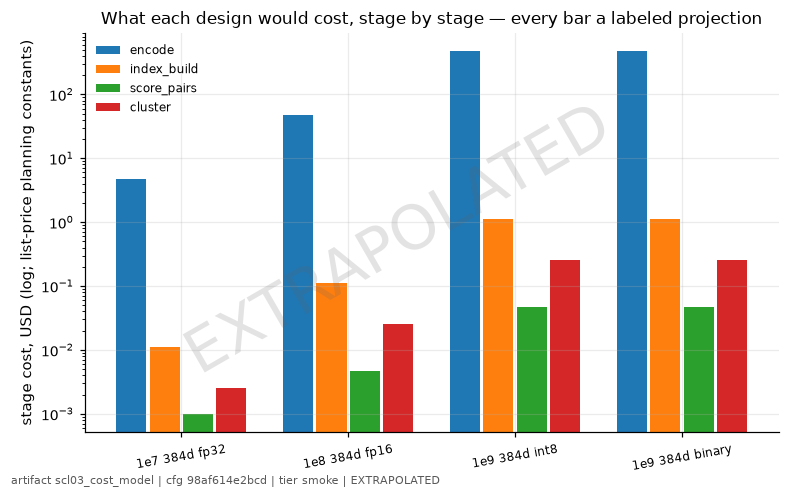

In [30]:
t_sec = time.time()
SCENARIOS = (
    ("1e7 384d fp32 (mac/node scale)", 1e7, 384 * 4.0),
    ("1e8 384d fp16", 1e8, 384 * 2.0),
    ("1e9 384d int8", 1e9, 384 * 1.0),
    ("1e9 384d binary", 1e9, 384 / 8.0),
)
frames = []
for label, n_rec, bpv in SCENARIOS:
    cm = CostModel({**COEFFS, "bytes_per_vector": bpv}, PRICES, measured_max_n=N_ARENA)
    bd = cm.breakdown(n_rec, {"candidates_per_record": K_CAND, "label": label})
    bd["scenario"], bd["n_records"], bd["bytes_per_vector"] = label, n_rec, bpv
    frames.append(bd)
    tot_t, tot_c = bd["time_h"].sum(), bd["cost_usd"].sum()
    print(f"[{label}] basis={bd['basis'].iloc[0]}: total {tot_t:,.1f} h, "
          f"${tot_c:,.0f}, peak stage memory {bd['memory_gb'].max():,.0f} GB "
          f"(vector store {n_rec * bpv / 1e9:,.0f} GB)")

# The single-node ceiling, demonstrated: 1e9 x 384-d fp32 = 1536 GB > the node's 900 GB.
_cm_fp32 = CostModel({**COEFFS, "bytes_per_vector": 384 * 4.0}, PRICES,
                     measured_max_n=N_ARENA)
CEILING_MSG = None
try:
    _cm_fp32.breakdown(1e9, {"candidates_per_record": K_CAND, "label": "1e9 384d fp32"})
except SingleNodeCeilingError as err:
    CEILING_MSG = str(err)
    print("\nSingleNodeCeilingError raised and caught (the 900 GB rail is real code):")
    print(f"  {CEILING_MSG}")
assert CEILING_MSG is not None, "the 1e9 fp32 design must hit the single-node ceiling"

scl03 = pd.concat(frames, ignore_index=True)
registry.register(
    "scl03_cost_model", scl03, cfg=cfg, tier=cfg.run.tier,
    meta={
        "coefficients": {k: float(v) for k, v in COEFFS.items()},
        "coefficient_provenance": COEFF_PROVENANCE,
        "prices": PRICES,
        "prices_note": "recorded cloud list-price planning constants (not measured); "
                       "encode is measured on THIS CPU container but priced at GPU rates "
                       "— a conservative upper bound; PLAN §8's planning number is ~20k "
                       "rec/s per A100 (~14 GPU-h at 1e9, ±2x)",
        "measured_max_n": N_ARENA,
        "basis_semantics": "MEASURED = n within the coefficients' measured range (this "
                           f"arena, {N_ARENA:,} at smoke; 1e7 at tier=target) — beyond it "
                           "every row is EXTRAPOLATED: linear-in-n scaling is itself the "
                           "assumption the label declares",
        "designs": [{"scenario": s, "n_records": n, "bytes_per_vector": b,
                     "candidates_per_record": K_CAND} for s, n, b in SCENARIOS],
        "ceiling_demo": {"design": "1e9 x 384d fp32 (1536 GB vector store)",
                         "error": CEILING_MSG,
                         "resolution": "EFF-01's int8/binary rows fit (384/48 GB) — "
                                       "compression, not more machines (PLAN §2: no "
                                       "multi-machine path exists)"},
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"\nregistered scl03_cost_model ({len(scl03)} stage rows, "
      f"{len(SCENARIOS)} feasible designs + the refused one in meta)")


def draw_cost(ax, df, meta):
    scen = list(dict.fromkeys(df["scenario"]))
    stages = list(dict.fromkeys(df["stage"]))
    offs = np.linspace(-0.3, 0.3, len(stages))
    for stage, off in zip(stages, offs):
        g = df[df["stage"] == stage].set_index("scenario").reindex(scen)
        ax.bar(np.arange(len(scen)) + off, np.maximum(g["cost_usd"], 1e-3), width=0.18,
               label=stage)
    ax.set_yscale("log")
    ax.set_xticks(range(len(scen)), [s.split(" (")[0] for s in scen], rotation=10,
                  fontsize=8)
    ax.set_ylabel("stage cost, USD (log; list-price planning constants)")
    ax.legend(loc="upper left", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="scl03_cost_model", draw=draw_cost,
    title="What each design would cost, stage by stage — every bar a labeled projection",
    figsize=(7.2, 4.5),
)
tick("§8b cost model + ceiling demo + register", t_sec)

## 9. SCL-04: the irreducible-ambiguity budget — what no matcher can fix

Even a perfect matcher cannot separate two people whose recorded fields agree exactly.
NB03 **measured** that mass on the real NC county subset (met06: unresolvable-fraction
per field set, NCID-keyed, with CIs); this section turns those registered aggregates into
an accounting and extrapolates it to national scale — **every extrapolated number
labeled, every assumption listed**. Two models bracket the truth: **pooled** (the whole
national pool can collide — a birthday-problem upper bound that assumes the county's
value-frequency structure nationally) and **partitioned** (geography-bearing field sets
only collide within a locality, so the measured county rate is the better national read).
Only registered NC aggregates appear here — no person-level value, nothing to mask.

In [31]:
t_sec = time.time()
met06, met06_meta = registry.load("met06_identifiability", tier=cfg.run.tier)
nc_align, nc_align_meta = registry.load("nc_align_summary", tier=cfg.run.tier)
MET06_PROVENANCE = (f"met06_identifiability run {met06_meta['created_at']} "
                    f"(cfg {met06_meta['config_hash']}, tier {met06_meta['tier']})")
N_COUNTY = int(met06_meta["extra"]["n_records"])
GEO_SETS = {"name+age+city", "all_roles"}  # field sets that carry locality
POOLS = (("NC statewide", 7_500_000), ("1e8", 100_000_000), ("US adult", 258_000_000))
print(f"measured base: {MET06_PROVENANCE}")
print(f"  snapshot {met06_meta['extra']['snapshot']}, counties "
      f"{nc_align_meta['extra']['counties']}, n={N_COUNTY:,} records, scope="
      f"{met06_meta['extra']['scope']}; entity key: {met06_meta['extra']['entity_key']}")
print("  (aggregates only per DATA_GOVERNANCE.md — no person-level NC value appears)")

ov = met06[met06["grouping"] == "overall"].set_index("field_set")
amb_rows: list[dict] = []
for fs, r in ov.iterrows():
    amb_rows.append({"field_set": fs, "model": "measured", "pool": "county subset",
                     "n_pool": N_COUNTY, "rate": float(r["rate"]),
                     "lo": float(r["ci_low"]), "hi": float(r["ci_high"]),
                     "partners_per_record": float(-np.log1p(-r["rate"])),
                     "basis": "MEASURED"})
    q = {k: -np.log1p(-float(r[c])) / (N_COUNTY - 1)
         for k, c in (("pt", "rate"), ("lo", "ci_low"), ("hi", "ci_high"))}
    for pool, n_pool in POOLS:
        lam = {k: v * (n_pool - 1) for k, v in q.items()}
        amb_rows.append({"field_set": fs, "model": "pooled", "pool": pool,
                         "n_pool": n_pool, "rate": float(1 - np.exp(-lam["pt"])),
                         "lo": float(1 - np.exp(-lam["lo"])),
                         "hi": float(1 - np.exp(-lam["hi"])),
                         "partners_per_record": float(lam["pt"]),
                         "basis": "EXTRAPOLATED"})
        if fs in GEO_SETS:
            amb_rows.append({"field_set": fs, "model": "partitioned", "pool": pool,
                             "n_pool": n_pool, "rate": float(r["rate"]),
                             "lo": float(r["ci_low"]), "hi": float(r["ci_high"]),
                             "partners_per_record": float(-np.log1p(-r["rate"])),
                             "basis": "EXTRAPOLATED"})
amb_df = pd.DataFrame(amb_rows)
ASSUMPTIONS = [
    ("A1 Poisson/birthday approximation: r(N) = 1 - exp(-q(N-1)) with q = "
     "-ln(1-r_county)/(n_county-1); collisions independent across records"),
    ("A2 pooled model: the national value-frequency distribution equals the audited "
     "county subset's — an UPPER bound for geography-bearing field sets (a national pool "
     "spreads over ~3.1e3 counties / ~3.3e4 ZCTAs; local surname clustering inflates "
     "county q); the partitioned model instead holds those sets at the measured county "
     "rate (locality caps the effective pool)"),
    ("A3 NC's field set has NO full DOB (age only, met06) — a full-DOB corpus cuts the "
     "collision mass sharply; the OH full-DOB contrast is SCL-04's target-tier arm "
     "(PLAN §4)"),
    ("A4 the measured rates are NCID-keyed upper bounds on true ambiguity: MET-05 "
     "measured duplicate/overlay NCID rates and NB03 showed the all-roles floor is "
     "contaminated by split identities pending adjudication"),
    ("A5 cohort effects (first-name fashion by birth year) and household structure are "
     "not modeled; pool sizes are recorded planning constants (US 18+ ~2.58e8)"),
]
registry.register(
    "scl04_ambiguity_budget", amb_df, cfg=cfg, tier=cfg.run.tier,
    meta={
        "sources": {"met06": MET06_PROVENANCE,
                    "nc_align": f"nc_align_summary run {nc_align_meta['created_at']}",
                    "counties": nc_align_meta["extra"]["counties"],
                    "snapshot": met06_meta["extra"]["snapshot"]},
        "models": {"measured": "the county-subset rate as registered by NB03 (CI from "
                               "met06)",
                   "pooled": "birthday-problem extrapolation under A1+A2 — upper bound",
                   "partitioned": "geography-bearing field sets held at the measured "
                                  "county rate (locality caps the pool) — the better "
                                  "national read for those sets"},
        "assumptions": ASSUMPTIONS,
        "governance": "aggregates only (DATA_GOVERNANCE.md); no person-level NC value",
        "field_sets": met06_meta["extra"]["field_sets"],
    },
)
print(f"\nregistered scl04_ambiguity_budget ({len(amb_df)} rows). The accounting:")
_p = amb_df[amb_df["pool"].isin(["county subset", "US adult"])]
display(_p.pivot_table(index="field_set", columns=["pool", "model"], values="rate")
        .round(4))
_ar_meas = float(ov.loc["all_roles", "rate"])
_ar_pool = float(amb_df[(amb_df["field_set"] == "all_roles")
                        & (amb_df["model"] == "pooled")
                        & (amb_df["pool"] == "US adult")]["rate"].iloc[0])
print(f"reading: on NC's no-full-DOB field set, the measured county-subset floor is "
      f"{_ar_meas:.2%} of records unresolvable (all roles agree); at US-adult scale the "
      f"pooled upper bound saturates to {_ar_pool:.1%} while the partitioned model holds "
      f"~{_ar_meas:.2%} — i.e. entity-recall ceilings of ~{1 - _ar_pool:.1%} vs "
      f"~{1 - _ar_meas:.2%}. The bracket is the finding: WHERE between them a real "
      "national pool lands is exactly what the OH full-DOB contrast (target tier) and "
      "assumption A2 decide; every non-county number above is EXTRAPOLATED arithmetic, "
      "not a measurement.")
tick("§9 ambiguity budget", t_sec)

measured base: met06_identifiability run 2026-08-26T01:56:27.888253+00:00 (cfg 129c9d9243ca, tier smoke)
  snapshot 20260101, counties [68], n=447,450 records, scope=county_subset_preliminary; entity key: ncid (audited by MET-05 — unresolvability is measured AGAINST this key)
  (aggregates only per DATA_GOVERNANCE.md — no person-level NC value appears)

registered scl04_ambiguity_budget (22 rows). The accounting:


pool             US adult         county subset
model         partitioned  pooled      measured
field_set                                      
all_roles          0.0103  0.9975        0.0103
name                  NaN  1.0000        0.0850
name+age              NaN  1.0000        0.0763
name+age+city      0.0535  1.0000        0.0535

reading: on NC's no-full-DOB field set, the measured county-subset floor is 1.03% of records unresolvable (all roles agree); at US-adult scale the pooled upper bound saturates to 99.7% while the partitioned model holds ~1.03% — i.e. entity-recall ceilings of ~0.3% vs ~98.97%. The bracket is the finding: WHERE between them a real national pool lands is exactly what the OH full-DOB contrast (target tier) and assumption A2 decide; every non-county number above is EXTRAPOLATED arithmetic, not a measurement.
[section timing] §9 ambiguity budget: 0s


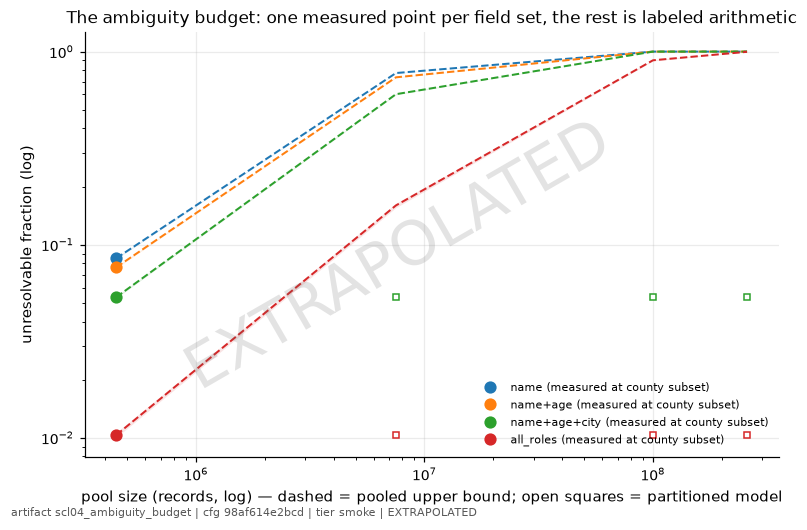

In [32]:
def draw_ambiguity(ax, df, meta):
    for i, fs in enumerate(["name", "name+age", "name+age+city", "all_roles"]):
        m = df[(df["field_set"] == fs) & (df["model"] == "measured")]
        p = df[(df["field_set"] == fs) & (df["model"] == "pooled")].sort_values("n_pool")
        seg = pd.concat([m, p])
        ax.plot(seg["n_pool"], seg["rate"], "--", color=f"C{i}", linewidth=1.3)
        ax.fill_between(seg["n_pool"], seg["lo"], seg["hi"], color=f"C{i}", alpha=0.12,
                        linewidth=0)
        ax.plot(m["n_pool"], m["rate"], "o", color=f"C{i}", markersize=7,
                label=f"{fs} (measured at county subset)")
        part = df[(df["field_set"] == fs) & (df["model"] == "partitioned")]
        if len(part):
            ax.plot(part["n_pool"], part["rate"], "s", color=f"C{i}", markersize=4,
                    markerfacecolor="white")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("pool size (records, log) — dashed = pooled upper bound; open squares "
                  "= partitioned model")
    ax.set_ylabel("unresolvable fraction (log)")
    ax.legend(loc="lower right", fontsize=7.5)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="scl04_ambiguity_budget", draw=draw_ambiguity,
    title="The ambiguity budget: one measured point per field set, the rest is labeled "
          "arithmetic",
    figsize=(7.2, 4.8),
)

## 10. The honest chain — what each hop adds, and what it cannot

- **smoke (this run)** proves the *machinery*: the ladder is entity-preserving and
  nested, the fits carry their own prediction intervals and refuse extrapolation when
  validation fails, the EVT gate refuses ξ where the tail did not earn it, the cost
  model refuses designs that outgrow the node, and every projected number is dashed and
  watermarked. The numbers themselves are single-seed demonstrations at 3.2e4 records.
- **mac (tier=mid)** adds the first real decade: the 1e5→1e6 ladder with met04-sized
  replicates, 1e6-pool tail fits, and the EFF-01 MRL/IVF-PQ factorial the smoke control
  arm only previews. Same cells, `run.tier=mid`.
- **node (tier=target)** adds the decisive rung: the 1e7 ladder SCL-01's card names as
  its adjudication, hub-scale tails for SCL-02, and — critically — it moves the cost
  model's MEASURED/EXTRAPOLATED boundary from 3.2e4 to 1e7, so the 1e8/1e9 rows become
  two extrapolated decades instead of five.
- **analytical (SCL-03/04)** is the only honest way to touch 1e8–1e9: arithmetic on
  node-measured coefficients under listed assumptions, plus the ambiguity budget that
  bounds what ANY design can achieve there. The chain never claims a 1e9 measurement —
  it claims a validated fit at 1e7, labeled arithmetic beyond it, and a floor no
  matcher crosses.

**Package gaps noted this notebook** (worked around in-notebook, per the series
convention): candidate-set PC bootstrap still notebook-local (NB12's gap);
`entity_complete_subsample` still copied (05/09/12/13/15); `blocking.ann` exposes no
index-build timing or reusable index handle (SCL-03 measures the build via faiss
directly); no per-stratum exact pair-exceedance counter in `scale.evt` (the block-matmul
counter here); `reporting.figures.scaling_curve` stamps one artifact, so the curve panel
is registered separately (`scl01_curve_panel`) rather than mixing figure-shaped rows
into the ledger.

**Artifacts registered** (exact names): `scl01_scaling_fits`, `scl02_tail_fits`,
`eff01_compression_matrix`, `scl03_cost_model`, `scl04_ambiguity_budget` — plus
supporting `scl01_curve_panel` and the immutable cards `card_SCL-01` and `card_SCL-02`.

In [33]:
timing = pd.DataFrame(SECTION_TIMES, columns=["section", "secs"])
display(timing.assign(secs=timing["secs"].round(0)))
total = time.time() - NB_T0
print(f"notebook wall-clock: {total:.0f}s ({total / 60:.1f} min) — smoke budget <= ~30 min "
      "uncontended"
      + ("" if total <= 2100 else "  <-- over that budget at this run (see section table; "
                                  "a concurrent notebook re-execution contends for these "
                                  "4 CPUs)"))

,section,secs
0,§1 arena + upstreams + instruments,1.0
1,§3a recipe retrain,54.0
2,§3b encode,22.0
3,§4a ladder rungs 1-3,8.0
4,§4b ladder rungs 4-5 + tables,14.0
5,§5a fits + validation + register,0.0
6,§6a per-stratum GPD fits + gate,2.0
7,§6b counting + predictions + register,59.0
8,§7a compression cells 1-8,34.0
9,§7b compression cells 9-16 + register + heatmap,22.0


notebook wall-clock: 229s (3.8 min) — smoke budget <= ~30 min uncontended
